In [97]:
import torch
import numpy as np
import pandas as pd

emb = torch.load(
    "embeddings_orth_loss/fold_4_embeddings.pt"
)

tissue_emb = emb["epoch99"]["tissue"]
plasma_emb = emb["epoch99"]["plasma"]


patients = sorted(
    set(tissue_emb.keys()) &
    set(plasma_emb.keys())
)

print(len(patients))

10


In [98]:
print(tissue_emb.keys())

dict_keys(['Sample 20', 'Sample 24', 'Sample 30', 'Sample 36', 'Sample 39', 'Sample 45', 'Sample 55', 'Sample 72', 'Sample 77', 'Sample 90'])


In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
def plot(pca_df, fold, proj = False, epoch=0):
    patients = sorted(
    set(pca_df["patient"])
    )

    # Create a color mapping for patients
    colors = cm.get_cmap("tab20", len(patients))
    patient_colors = {
        patient: colors(i)
        for i, patient in enumerate(patients)
    }

    plt.figure(figsize=(7,6))



    for patient in patients:

        color = patient_colors[patient]

        tissue = pca_df[
        (pca_df["patient"] == patient) &
        (pca_df["modality"] == "Tissue")
        ].iloc[0]

        plasma = pca_df[
        (pca_df["patient"] == patient) &
        (pca_df["modality"] == "Plasma")
        ].iloc[0]

        t = tissue[["PC1", "PC2"]].values
        p = plasma[["PC1", "PC2"]].values


        plt.scatter(
            t[0],
            t[1],
            marker="o",
            color = color,
            label="Tissue" if patient == patients[0] else ""
        )

        plt.scatter(
            p[0],
            p[1],
            marker="^",
            color=color,
            label="Plasma" if patient == patients[0] else ""

        )


        plt.plot(
            [t[0],p[0]],
            [t[1],p[1]],
            color=color,
            alpha=0.3
        )

    if proj == True:
        emb_type = 'projected embedding'
    else:
        emb_type = 'encoded embedding'
    plt.title(
        f"Patient-wise tissue-plasma {emb_type} alignment after {epoch} epochs"
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()


    # plt.savefig(f'embeddings/plots/embeddings_fold_{fold}_{epoch}_{emb_type}.png',
    #     bbox_inches="tight")
    plt.show()




In [2]:
def compute_PCA(plasma_emb, tissue_emb):
    X = []
    labels = []
    modalities = []
    patients = sorted(
        set(tissue_emb.keys()) &
        set(plasma_emb.keys())
    )

    for patient in patients:

        X.append(
            tissue_emb[patient].numpy()
        )
        labels.append(patient)
        modalities.append("Tissue")


        X.append(
            plasma_emb[patient].numpy()
        )
        labels.append(patient)
        modalities.append("Plasma")


    X = np.stack(X)
    pca = PCA(
        n_components=2
    )

    X_pca = pca.fit_transform(X)
    pca_df = pd.DataFrame({
    "patient": labels,
    "modality": modalities,
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1]
})
    return pca, pca_df


In [3]:
def paired_distances_per_pc(pca_df):

    pc_cols = [c for c in pca_df.columns if c.startswith("PC")]

    results = []

    for pc in pc_cols:

        distances = []

        for patient in pca_df["patient"].unique():

            tissue = pca_df[
                (pca_df.patient == patient) &
                (pca_df.modality == "Tissue")
            ][pc].values[0]

            plasma = pca_df[
                (pca_df.patient == patient) &
                (pca_df.modality == "Plasma")
            ][pc].values[0]

            distances.append(abs(tissue - plasma))

        results.append({
            "PC": pc,
            "mean_distance": np.mean(distances),
            "std_distance": np.std(distances)
        })

    return pd.DataFrame(results)

In [4]:
def modality_separation(pca_df):

    pc_cols = [c for c in pca_df.columns if c.startswith("PC")]

    results = []

    for pc in pc_cols:

        tissue_values = pca_df[
            pca_df["modality"] == "Tissue"
        ][pc]

        plasma_values = pca_df[
            pca_df["modality"] == "Plasma"
        ][pc]

        separation = abs(
            tissue_values.mean() -
            plasma_values.mean()
        )

        results.append({
            "PC": pc,
            "modality_separation": separation,
            "tissue_mean": tissue_values.mean(),
            "plasma_mean": plasma_values.mean()
        })

    return pd.DataFrame(results)

In [102]:
def visualize_embeddings(proj=False, trained = True):
    all_pc_distances = []
    all_pc_separations = []
    all_variance =[]
    pc_all_folds ={}

    for fold in range(5):
        if proj:
            emb = torch.load(
            f"embeddings_orth_loss/fold_{fold}_embeddings_proj.pt"
            )
            best_emb = torch.load(
                f"embeddings_orth_loss/fold_{fold}_best_embeddings_proj.pt"
            )
            
            tissue_emb_0 = emb["epoch0"]["tissue"]
            plasma_emb_0 = emb["epoch0"]["plasma"]
    
            tissue_emb_99 = best_emb["tissue"]
            plasma_emb_99 = best_emb["plasma"]
            print(f'best emb saved at epoch {best_emb["epoch"]}')
            
        else:
            emb = torch.load(
            f"embeddings_orth_loss/fold_{fold}_embeddings.pt"
            )
            

            tissue_emb_0 = emb["epoch0"]["tissue"]
            plasma_emb_0 = emb["epoch0"]["plasma"]
    
            tissue_emb_99 = emb["epoch99"]["tissue"]
            plasma_emb_99 = emb["epoch99"]["plasma"]
            
    
        pca_0, pca_0_df = compute_PCA(plasma_emb_0['shared'], tissue_emb_0['shared'])
        pca_99, pca_99_df = compute_PCA(plasma_emb_99['shared'], tissue_emb_99['shared'])
        
        
        from sklearn.metrics import roc_auc_score
        if trained == True:
            pca_99_df['fold']= fold
            pc_all_folds[fold] = pca_99_df.copy()
            for pc in ["PC1", "PC2"]:
    
                values = pca_99_df[pc].values
    
                labels = (
                    pca_99_df["modality"] == "Plasma"
                ).astype(int)
    
                auc = roc_auc_score(labels, values)
    
                print(pc, auc)
    
    
            distance = paired_distances_per_pc(pca_99_df)
            distance["fold"] = fold
            print(f'Distances Fold {fold}')
            print(distance)
    
            all_pc_distances.append(distance)
    
            separation = modality_separation(pca_99_df)
            separation["fold"] = fold
    
            print(f"Fold {fold} separation")
            print(separation)
            all_pc_separations.append(separation)
    
            explained_variance = pd.DataFrame({
            "PC": [f"PC{i+1}" for i in range(len(pca_99.explained_variance_ratio_))],
            "explained_variance": pca_99.explained_variance_ratio_,
            "fold": fold
            })
    
            all_variance.append(explained_variance)
    
            plt.bar(
            range(1,3),
            pca_99.explained_variance_ratio_,
            )
            plt.title(f'explained variance ratio for fold {fold}')
            plt.xlabel("PC")
            plt.ylabel("Explained variance")
            plt.show()
            plot(pca_0_df, fold=fold, proj=proj,epoch=0)
            plot(pca_99_df,fold=fold, proj=proj,epoch=99)
    
        else:
            pca_0_df['fold']= fold
            pc_all_folds[fold] = pca_0_df.copy()
            for pc in ["PC1", "PC2"]:
    
                values = pca_0_df[pc].values
    
                labels = (
                    pca_0_df["modality"] == "Plasma"
                ).astype(int)
    
                auc = roc_auc_score(labels, values)
    
                print(pc, auc)
    
    
            distance = paired_distances_per_pc(pca_0_df)
            distance["fold"] = fold
            print(f'Distances Fold {fold}')
            print(distance)
    
            all_pc_distances.append(distance)
    
            separation = modality_separation(pca_0_df)
            separation["fold"] = fold
    
            print(f"Fold {fold} separation")
            print(separation)
            all_pc_separations.append(separation)
    
            explained_variance = pd.DataFrame({
            "PC": [f"PC{i+1}" for i in range(len(pca_0.explained_variance_ratio_))],
            "explained_variance": pca_0.explained_variance_ratio_,
            "fold": fold
            })
    
            all_variance.append(explained_variance)
    
            plt.bar(
            range(1,3),
            pca_0.explained_variance_ratio_,
            )
            plt.title(f'explained variance ratio for fold {fold}')
            plt.xlabel("PC")
            plt.ylabel("Explained variance")
            plt.show()
            plot(pca_0_df, fold=fold, proj=proj,epoch=0)
            plot(pca_99_df,fold=fold, proj=proj,epoch=99)
        
    all_pc_distances = pd.concat(
    all_pc_distances,
    ignore_index=True
     )
    all_pc_separations = pd.concat(all_pc_separations,ignore_index=True)
    all_variance = pd.concat(all_variance,ignore_index=True)
    
    pc_all_folds_df = pd.concat(
    pc_all_folds.values(),
    ignore_index=True
    )
    print(pc_all_folds_df)
    
    return pc_all_folds_df, all_pc_distances, all_pc_separations, all_variance




best emb saved at epoch epoch69
PC1 0.08264462809917357
PC2 0.0
Distances Fold 0
    PC  mean_distance  std_distance  fold
0  PC1       0.222538      0.151505     0
1  PC2       0.166700      0.120660     0
Fold 0 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.215029     0.107514    -0.107514     0
1  PC2             0.166700     0.083350    -0.083350     0


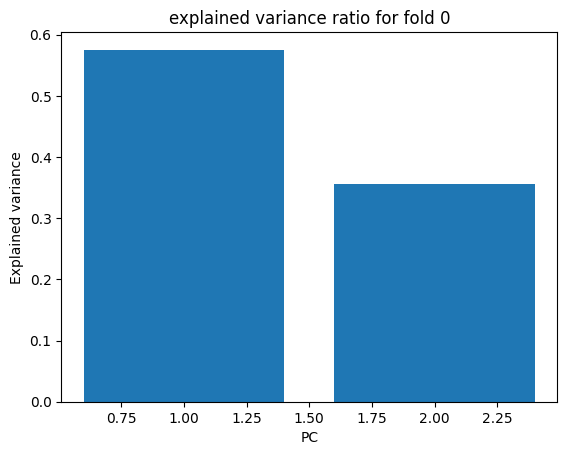

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


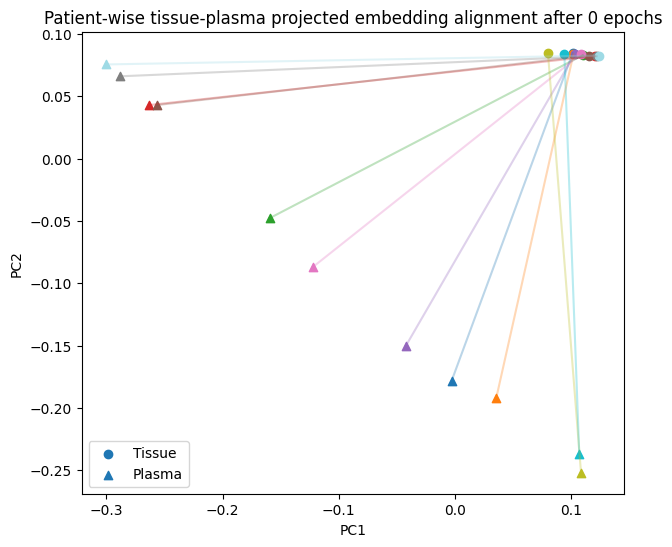

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


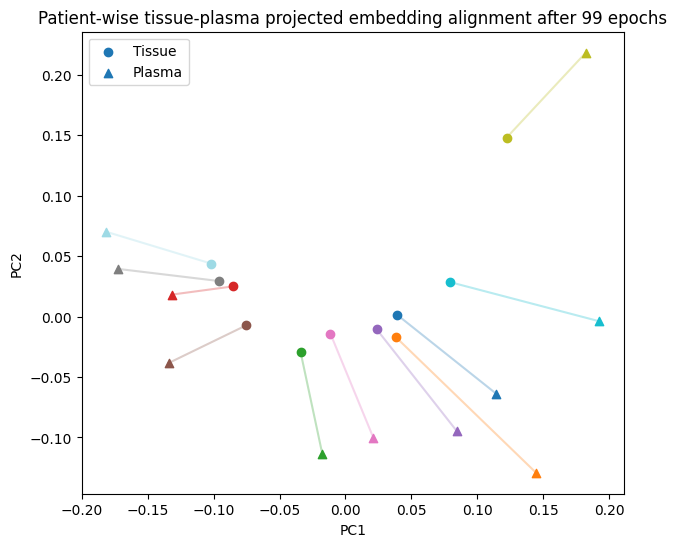

best emb saved at epoch epoch94
PC1 1.0
PC2 0.5537190082644627
Distances Fold 1
    PC  mean_distance  std_distance  fold
0  PC1       0.386372      0.094764     1
1  PC2       0.083152      0.107713     1
Fold 1 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.386372    -0.193186     0.193186     1
1  PC2             0.050363    -0.025181     0.025181     1


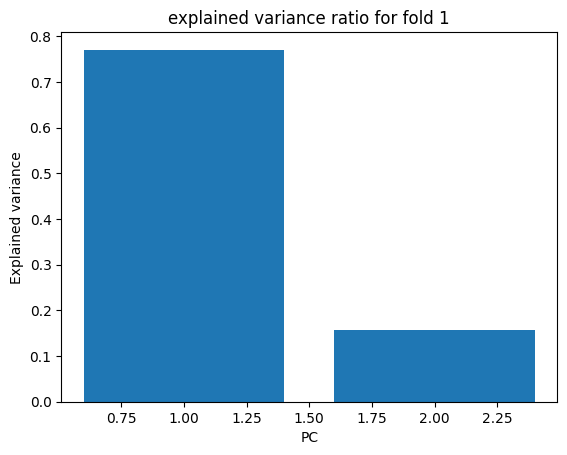

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


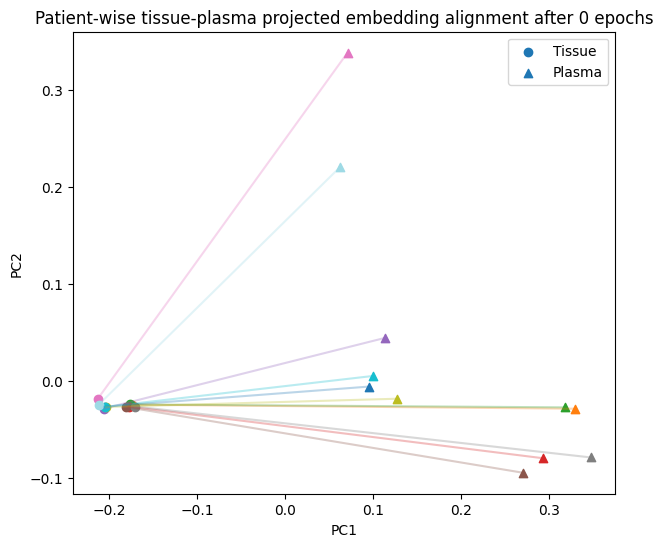

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


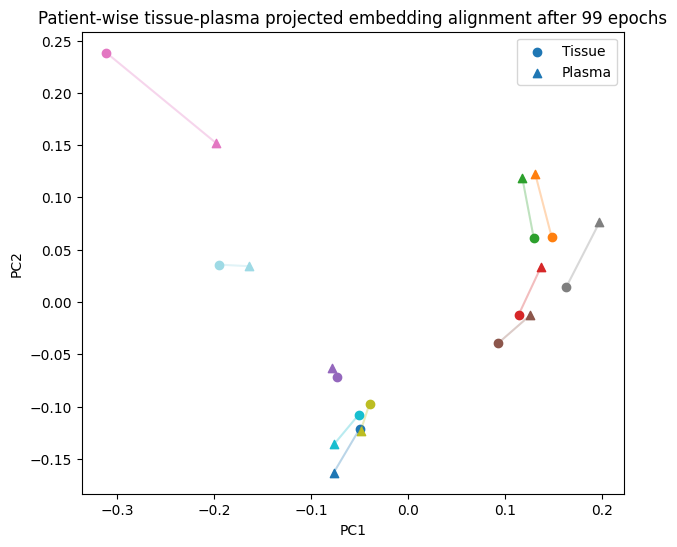

best emb saved at epoch epoch81
PC1 1.0
PC2 0.69
Distances Fold 2
    PC  mean_distance  std_distance  fold
0  PC1       0.414013      0.049567     2
1  PC2       0.097305      0.050958     2
Fold 2 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.414013    -0.207007     0.207007     2
1  PC2             0.027809    -0.013905     0.013905     2


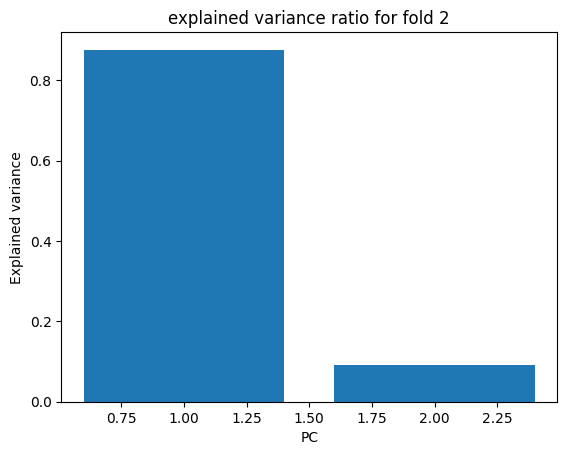

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


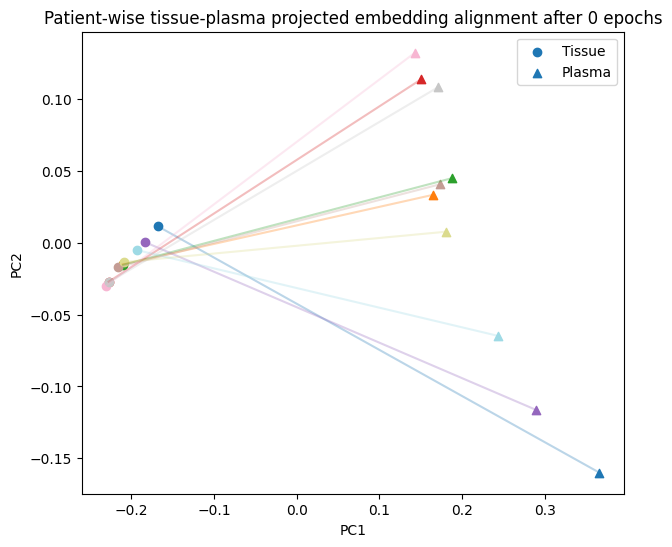

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


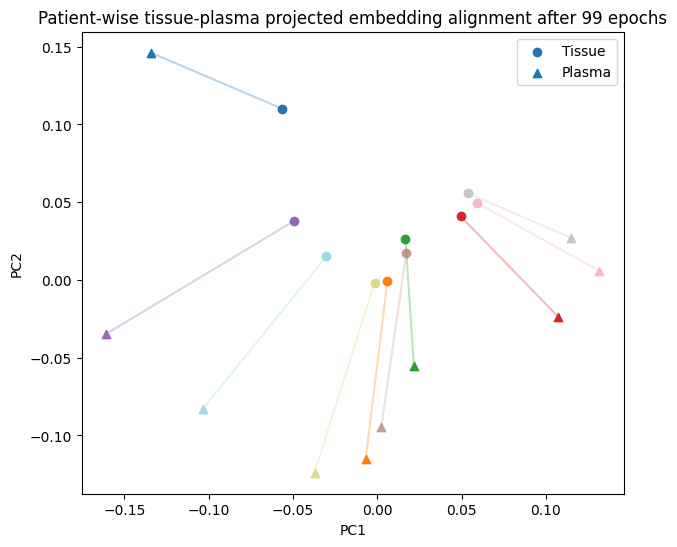

best emb saved at epoch epoch86
PC1 0.0
PC2 0.4
Distances Fold 3
    PC  mean_distance  std_distance  fold
0  PC1       0.408142      0.030583     3
1  PC2       0.189836      0.091271     3
Fold 3 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.408142     0.204071    -0.204071     3
1  PC2             0.004445    -0.002223     0.002223     3


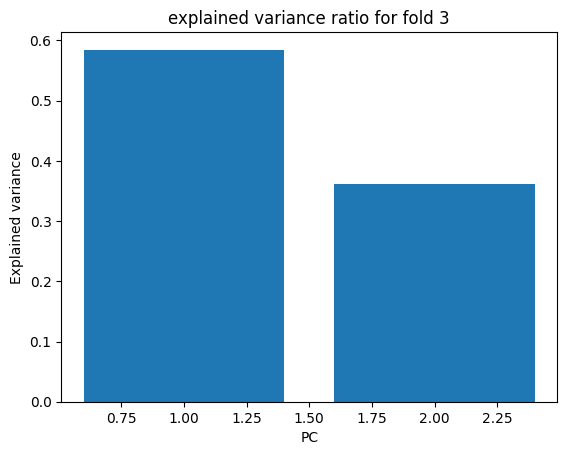

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


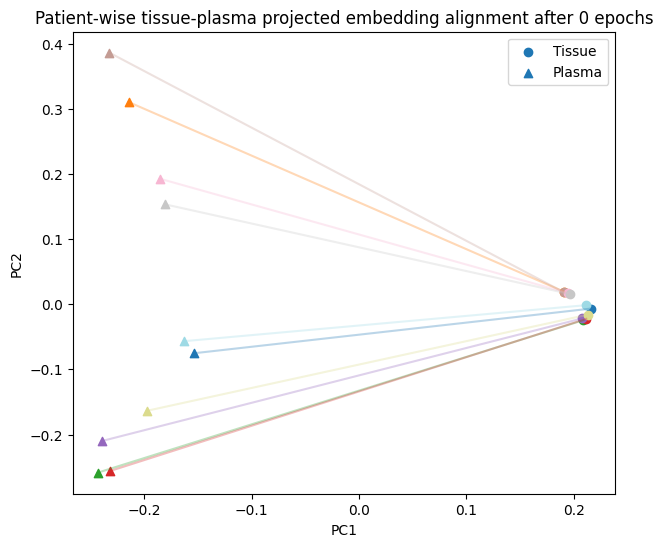

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


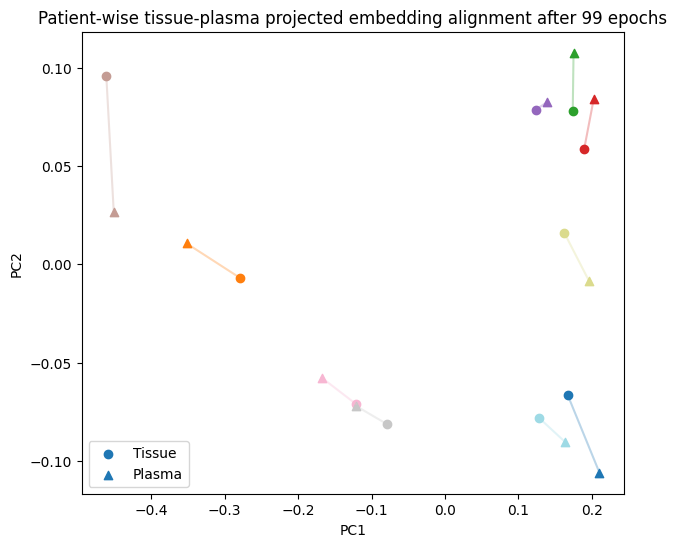

best emb saved at epoch epoch77
PC1 1.0
PC2 0.7
Distances Fold 4
    PC  mean_distance  std_distance  fold
0  PC1       0.325340      0.129053     4
1  PC2       0.146309      0.078766     4
Fold 4 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.325340    -0.162670     0.162670     4
1  PC2             0.103768    -0.051884     0.051884     4


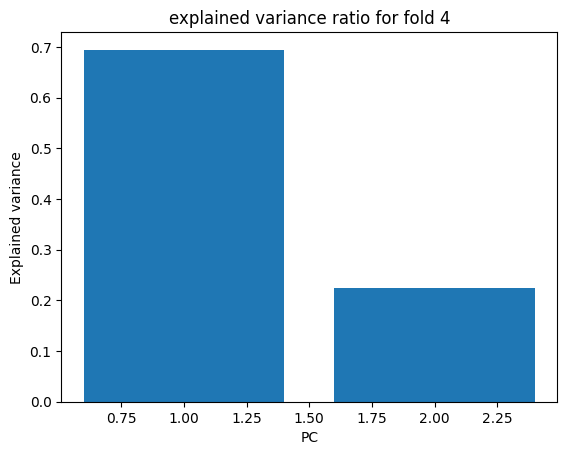

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


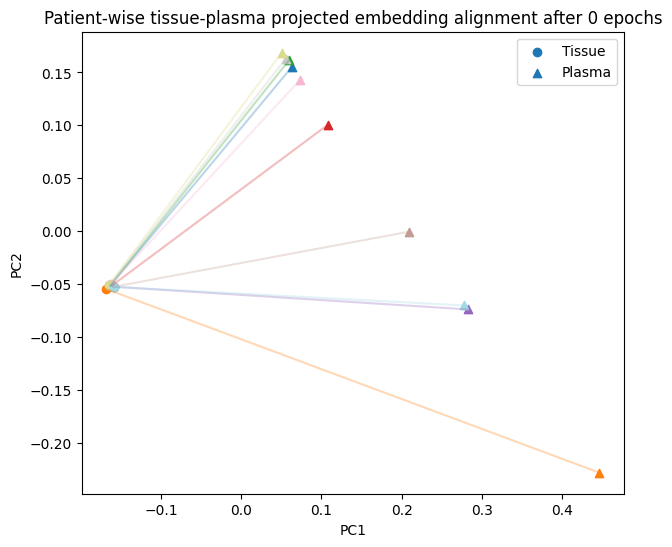

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


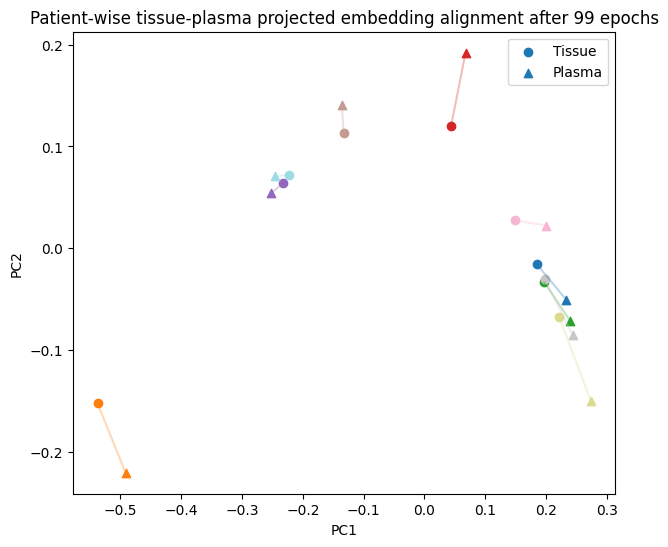

       patient modality       PC1       PC2  fold
0    Sample 15   Tissue  0.101319  0.084342     0
1    Sample 15   Plasma -0.002832 -0.178405     0
2    Sample 17   Tissue  0.102058  0.083596     0
3    Sample 17   Plasma  0.035666 -0.191961     0
4    Sample 28   Tissue  0.110166  0.082903     0
..         ...      ...       ...       ...   ...
99   Sample 72   Plasma  0.055200  0.162889     4
100  Sample 77   Tissue -0.165249 -0.051176     4
101  Sample 77   Plasma  0.050280  0.168612     4
102  Sample 90   Tissue -0.158586 -0.052691     4
103  Sample 90   Plasma  0.277928 -0.070285     4

[104 rows x 5 columns]


In [103]:
pc, all_distances, all_separations, all_variance = visualize_embeddings(proj=True, trained=False)

In [136]:
print(pc.head())

     patient modality       PC1       PC2  fold
0  Sample 15   Tissue -0.108386 -0.032394     0
1  Sample 15   Plasma  0.106132 -0.058019     0
2  Sample 17   Tissue -0.110124 -0.033065     0
3  Sample 17   Plasma  0.080879 -0.086715     0
4  Sample 28   Tissue -0.109873 -0.030569     0


best emb saved at epoch epoch69
PC1 0.5289256198347108
PC2 0.33884297520661155
Distances Fold 0
    PC  mean_distance  std_distance  fold
0  PC1       0.065954      0.027472     0
1  PC2       0.055375      0.033770     0
Fold 0 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.018528    -0.009264     0.009264     0
1  PC2             0.036003     0.018002    -0.018002     0


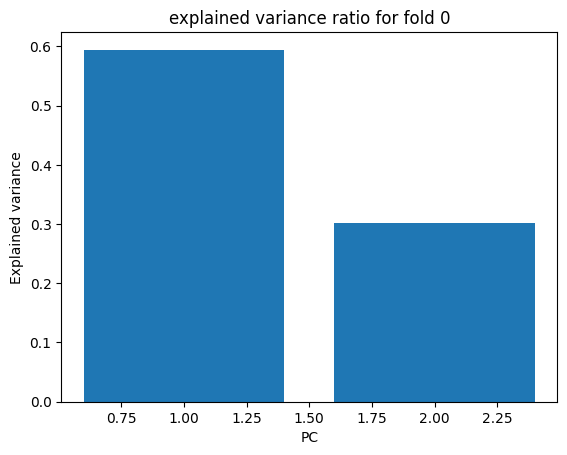

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


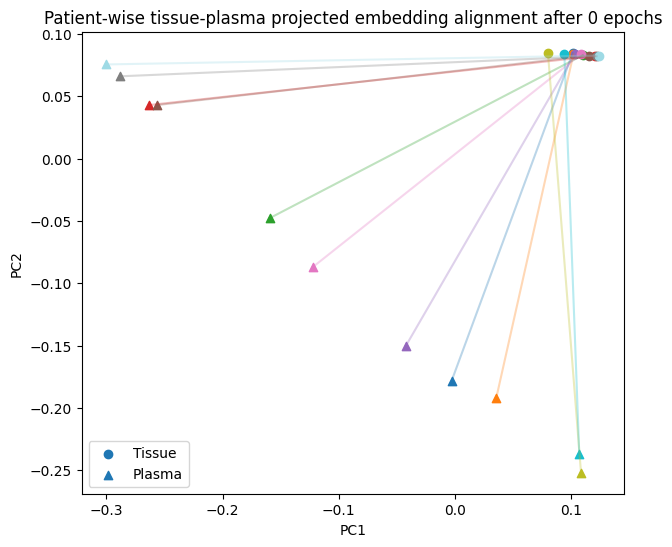

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


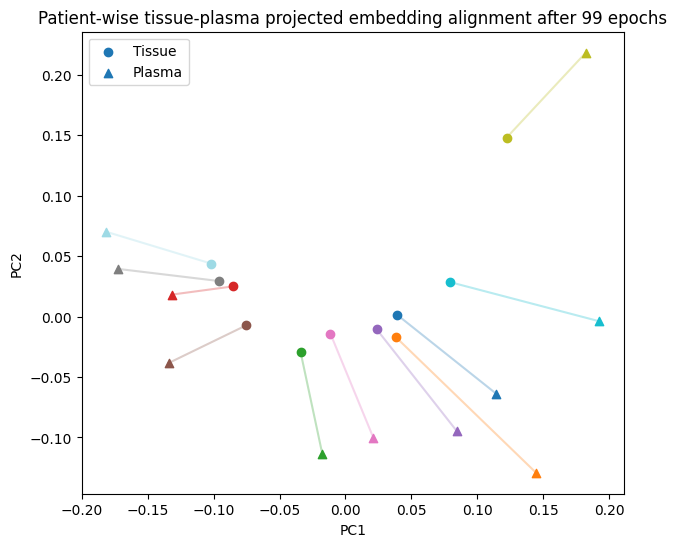

best emb saved at epoch epoch94
PC1 0.4876033057851239
PC2 0.5206611570247934
Distances Fold 1
    PC  mean_distance  std_distance  fold
0  PC1       0.029932      0.027805     1
1  PC2       0.040326      0.023911     1
Fold 1 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.012660     -0.00633      0.00633     1
1  PC2             0.006979     -0.00349      0.00349     1


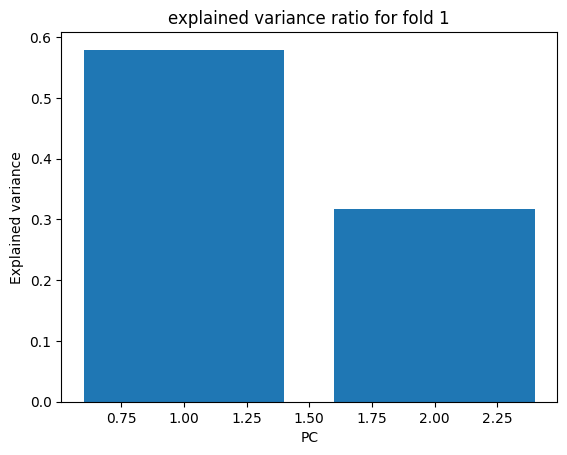

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


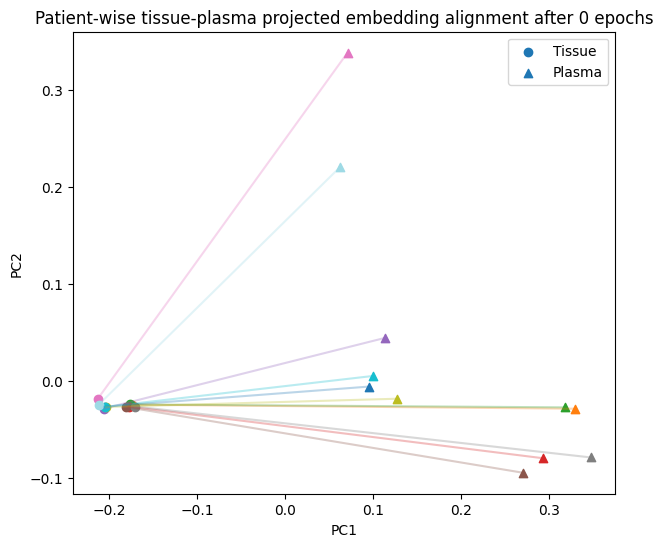

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


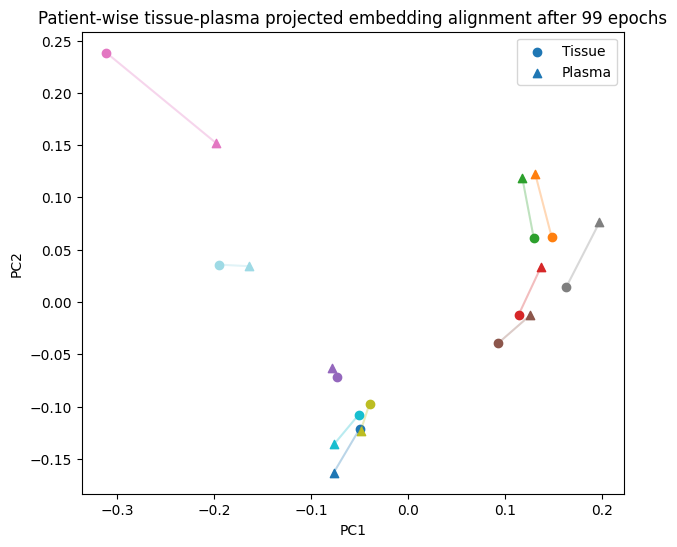

best emb saved at epoch epoch81
PC1 0.46
PC2 0.16999999999999998
Distances Fold 2
    PC  mean_distance  std_distance  fold
0  PC1       0.052228      0.032496     2
1  PC2       0.077390      0.032270     2
Fold 2 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.012883     0.006442    -0.006442     2
1  PC2             0.070211     0.035105    -0.035105     2


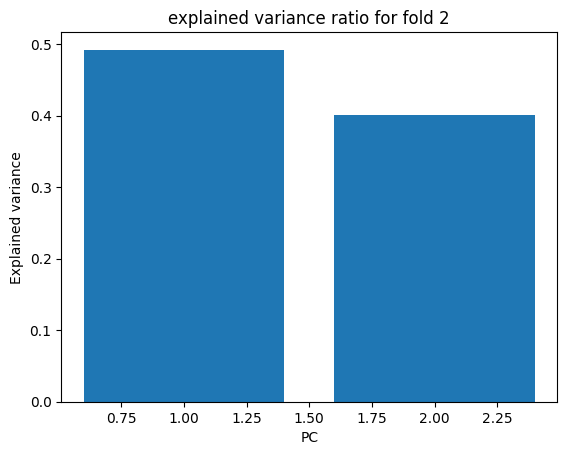

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


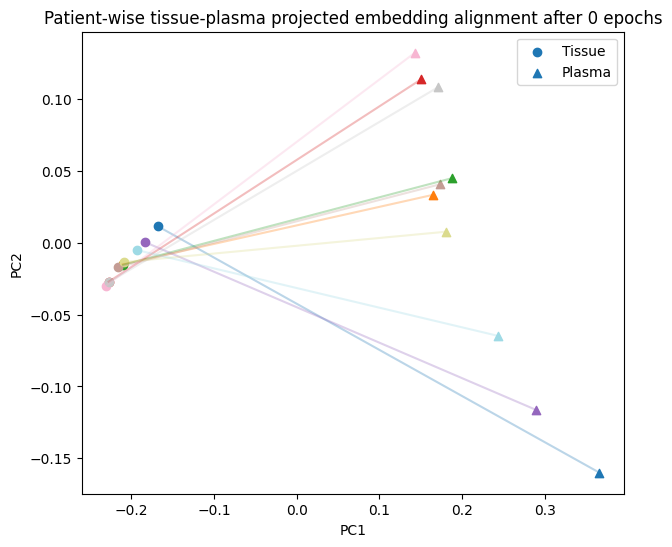

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


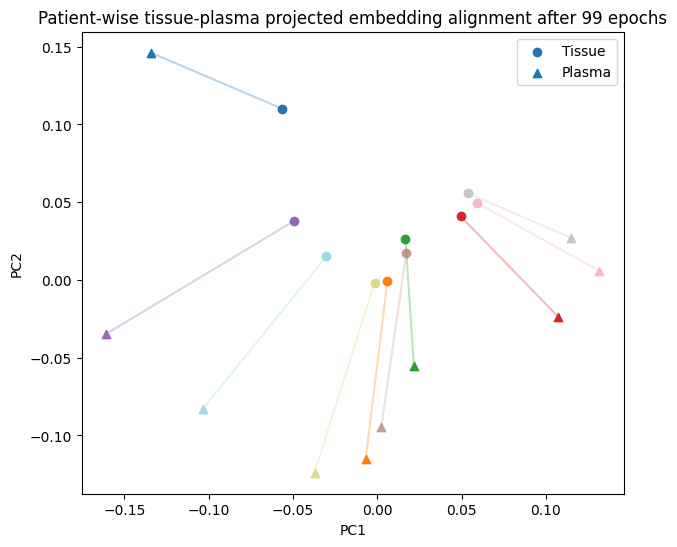

best emb saved at epoch epoch86
PC1 0.59
PC2 0.49000000000000005
Distances Fold 3
    PC  mean_distance  std_distance  fold
0  PC1       0.031365      0.020453     3
1  PC2       0.024429      0.017915     3
Fold 3 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.001036     0.000518    -0.000518     3
1  PC2             0.004593     0.002296    -0.002296     3


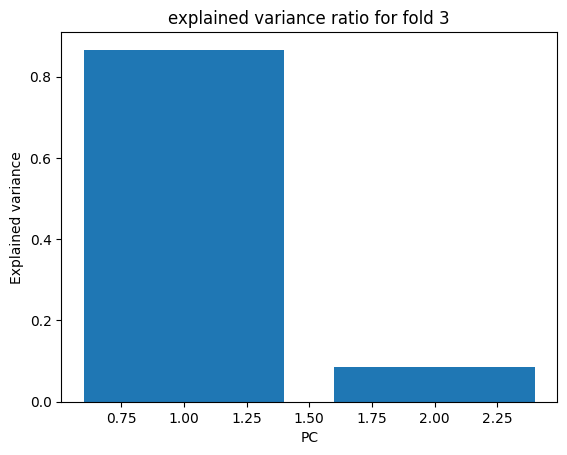

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


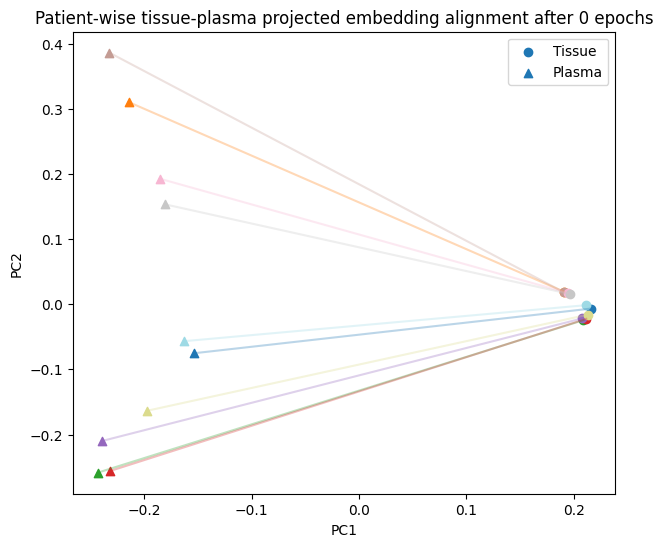

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


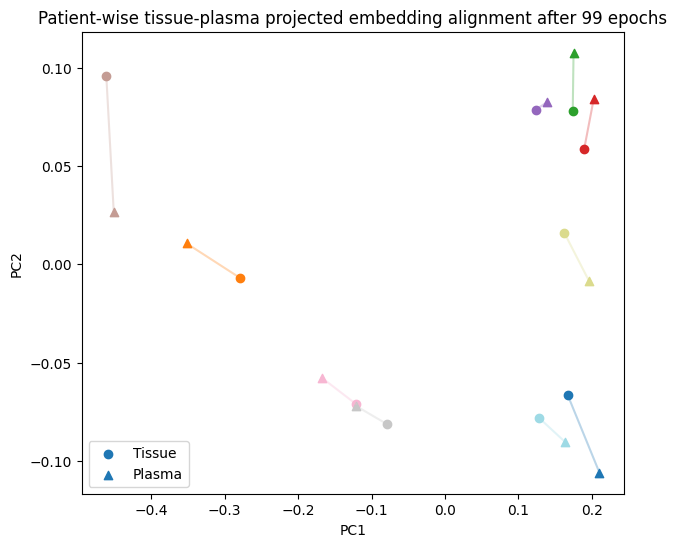

best emb saved at epoch epoch77
PC1 0.6
PC2 0.43
Distances Fold 4
    PC  mean_distance  std_distance  fold
0  PC1       0.035494      0.016097     4
1  PC2       0.039345      0.027508     4
Fold 4 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.026538    -0.013269     0.013269     4
1  PC2             0.019405     0.009703    -0.009703     4


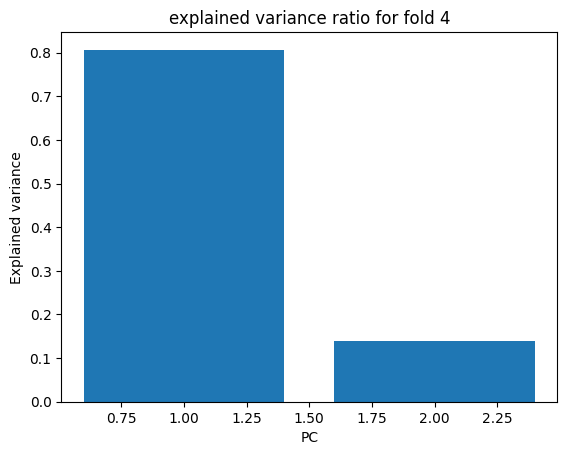

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


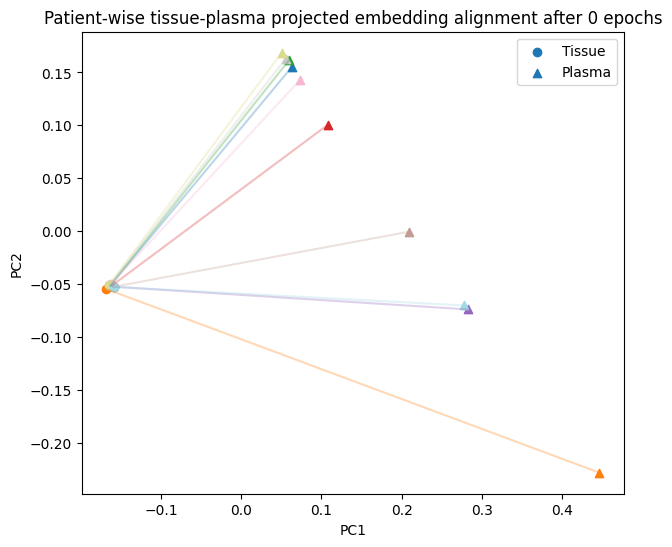

C:\Users\P095551\AppData\Local\Temp\ipykernel_7360\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


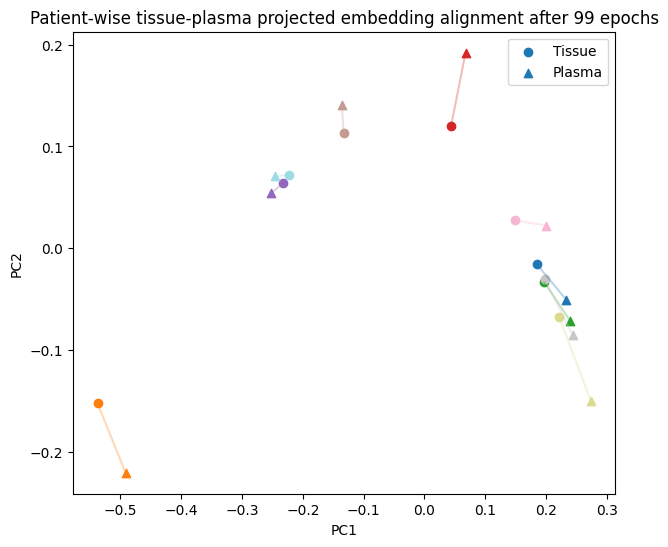

       patient modality       PC1       PC2  fold
0    Sample 15   Tissue  0.039320  0.001363     0
1    Sample 15   Plasma  0.114341 -0.063833     0
2    Sample 17   Tissue  0.038271 -0.017048     0
3    Sample 17   Plasma  0.144560 -0.129216     0
4    Sample 28   Tissue -0.034078 -0.029303     0
..         ...      ...       ...       ...   ...
99   Sample 72   Plasma  0.243365 -0.084802     4
100  Sample 77   Tissue  0.221497 -0.067653     4
101  Sample 77   Plasma  0.273331 -0.149770     4
102  Sample 90   Tissue -0.222379  0.072264     4
103  Sample 90   Plasma -0.245635  0.070537     4

[104 rows x 5 columns]


In [104]:
pc_trained, all_distances_trained, all_separations_trained, all_variance_trained = visualize_embeddings(proj=True,
                                                                                                        trained=True)

In [137]:
summary_df = (
    all_distances
    .groupby("PC")
    .agg(
        mean_distance_across_folds=("mean_distance", "mean"),
        std_distance_across_folds=("std_distance", "mean")

    )
    .reset_index()
)

print(summary_df)

    PC  mean_distance_across_folds  std_distance_across_folds
0  PC1                    0.214634                   0.172309
1  PC2                    0.132111                   0.085913


In [138]:
summary_df_2 = all_separations.groupby("PC").agg(
        mean_separation_across_folds=("modality_separation", "mean")).reset_index()


print(summary_df_2)

    PC  mean_separation_across_folds
0  PC1                      0.179164
1  PC2                      0.121732


In [139]:
print(all_distances)

    PC  mean_distance  std_distance  fold
0  PC1       0.204821      0.100052     0
1  PC2       0.108232      0.078270     0
2  PC1       0.202176      0.114160     1
3  PC2       0.246328      0.101552     1
4  PC1       0.130522      0.122470     2
5  PC2       0.062976      0.054094     2
6  PC1       0.240700      0.230900     3
7  PC2       0.102052      0.074735     3
8  PC1       0.294953      0.293963     4
9  PC2       0.140966      0.120917     4


In [140]:
variance_summary = (
    all_variance
    .groupby("PC")
    .agg(
        mean_variance=("explained_variance", "mean"),
        std_variance=("explained_variance", "std")
    )
    .reset_index()
)

print(variance_summary)

    PC  mean_variance  std_variance
0  PC1       0.723396      0.135457
1  PC2       0.238144      0.133582


In [105]:
tissue_scores = pd.read_csv('PR80_30/tissue_pathway_scores.csv')
plasma_scores = pd.read_csv('PR80_30/plasma_pathway_scores.csv')

In [106]:
tissue_scores.columns

Index(['Name', 'REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT',
       'REACTOME_ABC_TRANSPORTER_DISORDERS',
       'REACTOME_ABORTIVE_ELONGATION_OF_HIV_1_TRANSCRIPT_IN_THE_ABSENCE_OF_TAT',
       'REACTOME_ACTIVATION_OF_AMPK_DOWNSTREAM_OF_NMDARS',
       'REACTOME_ACTIVATION_OF_ANTERIOR_HOX_GENES_IN_HINDBRAIN_DEVELOPMENT_DURING_EARLY_EMBRYOGENESIS',
       'REACTOME_ACTIVATION_OF_APC_C_AND_APC_C_CDC20_MEDIATED_DEGRADATION_OF_MITOTIC_PROTEINS',
       'REACTOME_ACTIVATION_OF_BH3_ONLY_PROTEINS',
       'REACTOME_ACTIVATION_OF_GENE_EXPRESSION_BY_SREBF_SREBP',
       'REACTOME_ACTIVATION_OF_NF_KAPPAB_IN_B_CELLS',
       ...
       'REACTOME_UBIQUITIN_DEPENDENT_DEGRADATION_OF_CYCLIN_D',
       'REACTOME_UBIQUITIN_MEDIATED_DEGRADATION_OF_PHOSPHORYLATED_CDC25A',
       'REACTOME_UB_SPECIFIC_PROCESSING_PROTEASES', 'REACTOME_UCH_PROTEINASES',
       'REACTOME_UNFOLDED_PROTEIN_RESPONSE_UPR',
       'REACTOME_VASOPRESSIN_REGULATES_RENAL_WATER_HOMEOSTASIS_VIA_AQUAPORINS',
       'REACTOME_VEGFR

In [107]:
tissue_scores.head(10)

,Name,REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT,REACTOME_ABC_TRANSPORTER_DISORDERS,REACTOME_ABORTIVE_ELONGATION_OF_HIV_1_TRANSCRIPT_IN_THE_ABSENCE_OF_TAT,REACTOME_ACTIVATION_OF_AMPK_DOWNSTREAM_OF_NMDARS,REACTOME_ACTIVATION_OF_ANTERIOR_HOX_GENES_IN_HINDBRAIN_DEVELOPMENT_DURING_EARLY_EMBRYOGENESIS,REACTOME_ACTIVATION_OF_APC_C_AND_APC_C_CDC20_MEDIATED_DEGRADATION_OF_MITOTIC_PROTEINS,REACTOME_ACTIVATION_OF_BH3_ONLY_PROTEINS,REACTOME_ACTIVATION_OF_GENE_EXPRESSION_BY_SREBF_SREBP,REACTOME_ACTIVATION_OF_NF_KAPPAB_IN_B_CELLS,...,REACTOME_UBIQUITIN_DEPENDENT_DEGRADATION_OF_CYCLIN_D,REACTOME_UBIQUITIN_MEDIATED_DEGRADATION_OF_PHOSPHORYLATED_CDC25A,REACTOME_UB_SPECIFIC_PROCESSING_PROTEASES,REACTOME_UCH_PROTEINASES,REACTOME_UNFOLDED_PROTEIN_RESPONSE_UPR,REACTOME_VASOPRESSIN_REGULATES_RENAL_WATER_HOMEOSTASIS_VIA_AQUAPORINS,REACTOME_VEGFR2_MEDIATED_VASCULAR_PERMEABILITY,REACTOME_VIF_MEDIATED_DEGRADATION_OF_APOBEC3G,REACTOME_VIRAL_MESSENGER_RNA_SYNTHESIS,REACTOME_VISUAL_PHOTOTRANSDUCTION
0,Sample 1,0.231611,0.298565,-0.195656,0.381296,-0.024051,0.236285,0.244072,-0.038372,0.256376,...,0.341682,0.314423,0.139454,0.276862,0.098879,0.272895,0.037843,0.342408,-0.186140,0.291460
1,Sample 11,0.249809,0.311428,-0.145361,0.369537,0.021594,0.270736,0.160096,-0.080457,0.286346,...,0.362637,0.342491,0.155900,0.300522,0.140011,0.227154,0.079617,0.363096,-0.091134,0.209741
2,Sample 12,0.245607,0.298996,-0.103165,0.386007,0.061926,0.240159,0.170863,-0.100291,0.257481,...,0.333695,0.317007,0.140801,0.283895,0.145264,0.243143,0.016121,0.338643,-0.047944,0.204055
3,Sample 15,0.267959,0.319057,-0.028175,0.368957,0.111295,0.268607,0.191422,-0.068818,0.289242,...,0.360411,0.347080,0.163014,0.301537,0.191807,0.233654,0.026406,0.371245,0.011559,0.183519
4,Sample 16,0.080954,0.136135,-0.013793,0.407288,0.071336,0.109390,0.206257,-0.021286,0.137477,...,0.169867,0.155548,0.060919,0.176378,0.106016,0.066471,-0.035811,0.180530,-0.109426,0.237227
5,Sample 17,0.263611,0.326555,-0.048653,0.386287,0.120978,0.285668,0.187545,0.001708,0.313727,...,0.373950,0.356760,0.172577,0.326875,0.172487,0.254060,0.040117,0.376802,-0.011550,0.164714
6,Sample 18,0.246140,0.317383,-0.176115,0.420972,0.065872,0.281917,0.197777,0.097497,0.313148,...,0.374153,0.380325,0.181008,0.332504,0.063477,0.333444,0.048992,0.386628,-0.122900,0.218896
7,Sample 20,0.220372,0.294001,-0.156599,0.390108,0.001871,0.250885,0.211493,-0.122059,0.271023,...,0.353913,0.330931,0.149861,0.280305,0.099326,0.209509,0.064218,0.351140,-0.149736,0.229504
8,Sample 22,0.228273,0.295169,-0.086733,0.346790,0.130976,0.256718,0.204953,0.111702,0.283177,...,0.339758,0.341139,0.173733,0.292657,0.113617,0.335077,0.029222,0.359063,-0.038249,0.188179
9,Sample 23,0.228904,0.305627,-0.122767,0.358950,0.000534,0.269858,0.231695,-0.077087,0.287472,...,0.376997,0.361551,0.136495,0.299174,0.137576,0.200694,0.079511,0.373400,-0.131567,0.243298


In [108]:
plasma_scores.head()

,Name,REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT,REACTOME_ABC_TRANSPORTER_DISORDERS,REACTOME_ACTIVATION_OF_APC_C_AND_APC_C_CDC20_MEDIATED_DEGRADATION_OF_MITOTIC_PROTEINS,REACTOME_ACTIVATION_OF_NF_KAPPAB_IN_B_CELLS,REACTOME_ADAPTIVE_IMMUNE_SYSTEM,REACTOME_ADHERENS_JUNCTIONS_INTERACTIONS,REACTOME_AEROBIC_RESPIRATION_AND_RESPIRATORY_ELECTRON_TRANSPORT,REACTOME_AMPK_INDUCED_ERAD_AND_LYSOSOME_MEDIATED_DEGRADATION_OF_PD_L1_CD274,REACTOME_AMYLOID_FIBER_FORMATION,...,REACTOME_TRANS_GOLGI_NETWORK_VESICLE_BUDDING,REACTOME_UBIQUITIN_DEPENDENT_DEGRADATION_OF_CYCLIN_D,REACTOME_UBIQUITIN_MEDIATED_DEGRADATION_OF_PHOSPHORYLATED_CDC25A,REACTOME_UB_SPECIFIC_PROCESSING_PROTEASES,REACTOME_UCH_PROTEINASES,REACTOME_UNFOLDED_PROTEIN_RESPONSE_UPR,REACTOME_VESICLE_MEDIATED_TRANSPORT,REACTOME_VIF_MEDIATED_DEGRADATION_OF_APOBEC3G,REACTOME_VIRAL_INFECTION_PATHWAYS,REACTOME_VISUAL_PHOTOTRANSDUCTION
0,Sample 1,0.096858,0.094984,0.058428,0.050090,0.106321,0.125298,-0.258689,0.063392,0.328135,...,-0.065754,0.058428,0.033120,-0.034562,0.069751,0.028000,0.074485,0.041592,0.167076,0.403302
1,Sample 11,0.086372,0.085952,0.043967,0.043127,0.179332,0.110591,0.177043,0.063402,0.350792,...,0.087497,0.043967,0.037454,0.040187,0.059640,0.127488,0.217874,0.041916,0.200743,0.332635
2,Sample 12,0.123927,0.126023,0.126900,0.118129,0.107311,0.141891,-0.203747,0.118197,0.330911,...,-0.153949,0.126900,0.100773,0.021849,0.101102,0.056165,0.047658,0.091935,0.142015,0.385659
3,Sample 15,0.204250,0.214317,0.168489,0.149088,0.164303,0.178233,-0.138344,0.180766,0.293720,...,-0.035744,0.168489,0.138505,0.100617,0.159640,0.036210,0.158433,0.128664,0.195283,0.390870
4,Sample 16,0.119520,0.127293,0.087322,0.074436,0.175624,0.173273,-0.032673,0.100792,0.308711,...,-0.054808,0.087322,0.061651,0.045543,0.088421,0.047517,0.168302,0.054053,0.206920,0.341060


In [109]:
pathways_1 = set(tissue_scores.columns).intersection(plasma_scores.columns) 
#pathways_1.remove('patient')
pathways_1.discard('Name')
print(pathways_1)

{'REACTOME_UNFOLDED_PROTEIN_RESPONSE_UPR', 'REACTOME_CARGO_TRAFFICKING_TO_THE_PERICILIARY_MEMBRANE', 'REACTOME_FCERI_MEDIATED_MAPK_ACTIVATION', 'REACTOME_PROGRAMMED_CELL_DEATH', 'REACTOME_RAB_GEFS_EXCHANGE_GTP_FOR_GDP_ON_RABS', 'REACTOME_INTRINSIC_PATHWAY_OF_FIBRIN_CLOT_FORMATION', 'REACTOME_EPH_EPHRIN_SIGNALING', 'REACTOME_METABOLISM_OF_CARBOHYDRATES_AND_CARBOHYDRATE_DERIVATIVES', 'REACTOME_GLYCOSAMINOGLYCAN_METABOLISM', 'REACTOME_SIGNALING_BY_NOTCH4', 'REACTOME_TRANSCRIPTIONAL_REGULATION_BY_RUNX1', 'REACTOME_TRANS_GOLGI_NETWORK_VESICLE_BUDDING', 'REACTOME_DOWNSTREAM_TCR_SIGNALING', 'REACTOME_INTERFERON_SIGNALING', 'REACTOME_SCF_SKP2_MEDIATED_DEGRADATION_OF_P27_P21', 'REACTOME_APOPTOTIC_CLEAVAGE_OF_CELLULAR_PROTEINS', 'REACTOME_CELL_SURFACE_INTERACTIONS_AT_THE_VASCULAR_WALL', 'REACTOME_SIGNALING_BY_MET', 'REACTOME_TRANSCRIPTIONAL_REGULATION_BY_RUNX2', 'REACTOME_FACTORS_INVOLVED_IN_MEGAKARYOCYTE_DEVELOPMENT_AND_PLATELET_PRODUCTION', 'REACTOME_NUCLEAR_ENVELOPE_NE_REASSEMBLY', 'REACTOME_

In [110]:
print(pc.head())

     patient modality       PC1       PC2  fold
0  Sample 15   Tissue  0.101319  0.084342     0
1  Sample 15   Plasma -0.002832 -0.178405     0
2  Sample 17   Tissue  0.102058  0.083596     0
3  Sample 17   Plasma  0.035666 -0.191961     0
4  Sample 28   Tissue  0.110166  0.082903     0


In [111]:
tissue_pc = pc[
    pc["modality"] == "Tissue"
]
print(tissue_pc.head())
plasma_pc = pc[pc['modality'] == 'Plasma']
print(plasma_pc.head())
tissue_scores = tissue_scores.rename(columns={"Name": "patient"})
plasma_scores = plasma_scores.rename(columns={"Name": "patient"})

merged_plasma = plasma_pc.merge(
    plasma_scores,
    on="patient",
    how="inner"
)
merged_tissue = tissue_pc.merge(
    tissue_scores,
    on="patient",
    how="inner"
)

     patient modality       PC1       PC2  fold
0  Sample 15   Tissue  0.101319  0.084342     0
2  Sample 17   Tissue  0.102058  0.083596     0
4  Sample 28   Tissue  0.110166  0.082903     0
6  Sample 29   Tissue  0.120434  0.082119     0
8  Sample 34   Tissue  0.103384  0.084054     0
     patient modality       PC1       PC2  fold
1  Sample 15   Plasma -0.002832 -0.178405     0
3  Sample 17   Plasma  0.035666 -0.191961     0
5  Sample 28   Plasma -0.159299 -0.047748     0
7  Sample 29   Plasma -0.263235  0.042872     0
9  Sample 34   Plasma -0.042109 -0.150092     0


In [112]:
from scipy.stats import pearsonr, spearmanr
merged = tissue_scores.merge(
    plasma_scores,
    on="patient",
    suffixes=("_tissue", "_plasma")
)

results = []

for pathway in pathways_1:

    tissue_col = f"{pathway}_tissue"
    plasma_col = f"{pathway}_plasma"

    # Only keep patients with both scores
    valid = merged[[tissue_col, plasma_col]].dropna()

    if len(valid) < 3:
        continue

    pearson_r, pearson_p = pearsonr(
        valid[tissue_col],
        valid[plasma_col]
    )

    spearman_r, spearman_p = spearmanr(
        valid[tissue_col],
        valid[plasma_col]
    )

    results.append({
        "pathway": pathway,
        "n": len(valid),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p
    })

pathway_correlations = pd.DataFrame(results)


      patient modality       PC1       PC2  fold  \
0   Sample 15   Tissue -0.108386 -0.032394     0   
1   Sample 17   Tissue -0.110124 -0.033065     0   
2   Sample 28   Tissue -0.109873 -0.030569     0   
3   Sample 29   Tissue -0.094850 -0.023718     0   
4   Sample 34   Tissue -0.110183 -0.032522     0   
5   Sample 38   Tissue -0.099050 -0.025389     0   
6   Sample 61   Tissue -0.112108 -0.032271     0   
7   Sample 76   Tissue -0.091647 -0.022262     0   
8   Sample 78   Tissue -0.096925 -0.030818     0   
9   Sample 85   Tissue -0.103912 -0.032086     0   
10  Sample 88   Tissue -0.089457 -0.021295     0   
11  Sample 16   Tissue -0.013586 -0.143473     1   
12  Sample 18   Tissue -0.016005 -0.107147     1   
13  Sample 22   Tissue -0.016222 -0.112067     1   
14  Sample 31   Tissue -0.017882 -0.118526     1   
15  Sample 49   Tissue -0.010346 -0.135856     1   
16  Sample 51   Tissue -0.018315 -0.124218     1   
17  Sample 64   Tissue  0.002353 -0.106678     1   
18  Sample 6

In [113]:
pc_trained = pc_trained.rename(
    columns={
        col: f"trained_{col}"
        for col in pc_trained.columns
        if col.startswith("PC")
    }
)
pc = pc.merge(
    pc_trained,
    on=["patient", "modality","fold"],
    how="left"
)

In [114]:
tissue_pc = pc[
    pc["modality"] == "Tissue"
]
print(tissue_pc.head())
plasma_pc = pc[pc['modality'] == 'Plasma']
print(plasma_pc.head())
tissue_scores = tissue_scores.rename(columns={"Name": "patient"})
plasma_scores = plasma_scores.rename(columns={"Name": "patient"})

merged_plasma = plasma_pc.merge(
    plasma_scores,
    on="patient",
    how="inner"
)
merged_tissue = tissue_pc.merge(
    tissue_scores,
    on="patient",
    how="inner"
)

     patient modality       PC1       PC2  fold  trained_PC1  trained_PC2
0  Sample 15   Tissue  0.101319  0.084342     0     0.039320     0.001363
2  Sample 17   Tissue  0.102058  0.083596     0     0.038271    -0.017048
4  Sample 28   Tissue  0.110166  0.082903     0    -0.034078    -0.029303
6  Sample 29   Tissue  0.120434  0.082119     0    -0.085190     0.025028
8  Sample 34   Tissue  0.103384  0.084054     0     0.023689    -0.010565
     patient modality       PC1       PC2  fold  trained_PC1  trained_PC2
1  Sample 15   Plasma -0.002832 -0.178405     0     0.114341    -0.063833
3  Sample 17   Plasma  0.035666 -0.191961     0     0.144560    -0.129216
5  Sample 28   Plasma -0.159299 -0.047748     0    -0.017508    -0.114017
7  Sample 29   Plasma -0.263235  0.042872     0    -0.131879     0.018190
9  Sample 34   Plasma -0.042109 -0.150092     0     0.084233    -0.094443


In [115]:
from scipy.stats import pearsonr, spearmanr


def correlate_pc_pathways(df, pc_cols=("PC1", "PC2","trained_PC1","trained_PC2")):
    results = []

    # pathway columns = everything except metadata + PCs
    metadata = {"patient", "modality", "fold", "Name"}
    pathway_cols = [
        col for col in df.columns
        if col not in metadata and col not in pc_cols
    ]

    for pc in pc_cols:
        for pathway in pathway_cols:

            # Remove missing values for this particular pair
            valid = df[[pc, pathway]].dropna()

            if len(valid) < 3:
                continue

            pearson_r, pearson_p = pearsonr(
                valid[pc],
                valid[pathway]
            )

            spearman_r, spearman_p = spearmanr(
                valid[pc],
                valid[pathway]
            )

            results.append({
                "PC": pc,
                "pathway": pathway,
                "n": len(valid),
                "pearson_r": pearson_r,
                "pearson_p": pearson_p,
                "spearman_r": spearman_r,
                "spearman_p": spearman_p
            })

    return pd.DataFrame(results)

In [116]:
from statsmodels.stats.multitest import multipletests

def add_fdr(results):

    results = results.copy()

    results["pearson_fdr"] = multipletests(
        results["pearson_p"],
        method="fdr_bh"
    )[1]

    results["spearman_fdr"] = multipletests(
        results["spearman_p"],
        method="fdr_bh"
    )[1]

    return results

In [117]:
tissue_results = []

for fold in range(5):

    fold_df = merged_tissue[
        merged_tissue["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    tissue_results.append(result)

tissue_results = pd.concat(
    tissue_results,
    ignore_index=True
)

tissue_results.sort_values(
    "pearson_r",
    ascending=False
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold
14770,trained_PC1,REACTOME_RND2_GTPASE_CYCLE,10,0.936036,0.000068,0.939394,0.000055,4
4411,PC2,REACTOME_PI_METABOLISM,11,0.920845,0.000058,0.836364,0.001333,1
1704,trained_PC1,REACTOME_DAP12_INTERACTIONS,11,0.906337,0.000120,0.790909,0.003746,0
13983,PC2,REACTOME_RND2_GTPASE_CYCLE,10,0.890519,0.000550,0.903030,0.000344,4
1705,trained_PC1,REACTOME_DAP12_SIGNALING,11,0.889612,0.000246,0.781818,0.004473,0
13984,PC2,REACTOME_RND3_GTPASE_CYCLE,10,0.887875,0.000603,0.975758,0.000001,4
10630,PC2,REACTOME_MOLECULES_ASSOCIATED_WITH_ELASTIC_FIBRES,10,0.881696,0.000741,0.866667,0.001174,3
10424,PC2,REACTOME_ELASTIC_FIBRE_FORMATION,10,0.876399,0.000877,0.866667,0.001174,3
10914,PC2,REACTOME_SIGNALING_BY_TGF_BETA_RECEPTOR_COMPLEX,10,0.875753,0.000895,0.842424,0.002220,3
14771,trained_PC1,REACTOME_RND3_GTPASE_CYCLE,10,0.866594,0.001176,0.781818,0.007547,4


In [118]:
plasma_results = []

for fold in range(5):

    fold_df = merged_plasma[
        merged_plasma["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    plasma_results.append(result)

plasma_results = pd.concat(
    plasma_results,
    ignore_index=True
)
plasma_results.sort_values(
    "pearson_r",
    ascending=False
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold
1949,trained_PC1,REACTOME_CILIUM_ASSEMBLY,11,0.988445,1.103170e-08,0.936364,0.000022,1
5950,trained_PC1,REACTOME_RHO_GTPASES_ACTIVATE_WASPS_AND_WAVES,10,0.986972,1.240673e-07,0.878788,0.000814,4
1952,trained_PC1,REACTOME_CLATHRIN_MEDIATED_ENDOCYTOSIS,11,0.986940,1.910029e-08,0.909091,0.000106,1
1977,trained_PC1,REACTOME_DENGUE_VIRUS_GENOME_TRANSLATION_AND_R...,11,0.984182,4.505214e-08,0.945455,0.000011,1
2095,trained_PC1,REACTOME_ORGANELLE_BIOGENESIS_AND_MAINTENANCE,11,0.984132,4.569395e-08,0.954545,0.000005,1
1989,trained_PC1,REACTOME_DISEASES_OF_SIGNAL_TRANSDUCTION_BY_GR...,11,0.984125,4.578989e-08,0.954545,0.000005,1
2130,trained_PC1,REACTOME_REGULATION_OF_PLK1_ACTIVITY_AT_G2_M_T...,11,0.982351,7.355184e-08,0.927273,0.000040,1
2063,trained_PC1,REACTOME_MEMBRANE_TRAFFICKING,11,0.980918,1.043021e-07,0.927273,0.000040,1
2156,trained_PC1,REACTOME_SARS_COV_1_INFECTION,11,0.980515,1.145250e-07,0.936364,0.000022,1
5438,PC2,REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSI...,10,0.978488,9.129892e-07,0.939394,0.000055,4


#### Cross modality pathway correlation

In [119]:
### Correlate tissue pc values with plasma pathway scores 
plasma_pathways = plasma_scores.copy()
tissue_pc_plasma_pathways = tissue_pc.merge(
    plasma_pathways,
    on="patient",
    how="inner"
)
cross_tissue_to_plasma = []

for fold in range(5):

    fold_df = tissue_pc_plasma_pathways[
        tissue_pc_plasma_pathways["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    cross_tissue_to_plasma.append(result)

cross_tissue_to_plasma = pd.concat(
    cross_tissue_to_plasma,
    ignore_index=True
)
cross_tissue_to_plasma.sort_values(
    "pearson_r",
    ascending=False
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold
2046,trained_PC1,REACTOME_INTERFERON_SIGNALING,11,0.985369,3.176728e-08,0.909091,1.055934e-04,1
5589,PC2,REACTOME_PLATELET_ACTIVATION_SIGNALING_AND_AGG...,10,0.984264,2.632110e-07,0.927273,1.120345e-04,4
1916,trained_PC1,REACTOME_ANTIMICROBIAL_MECHANISM_OF_IFN_STIMUL...,11,0.984139,4.560104e-08,0.936364,2.208208e-05,1
1429,PC1,REACTOME_MEMBRANE_TRAFFICKING,11,0.982719,6.694055e-08,0.854545,8.066742e-04,1
397,PC2,REACTOME_DEVELOPMENTAL_CELL_LINEAGES_OF_THE_EX...,11,0.981652,8.751659e-08,0.945455,1.118304e-05,0
401,PC2,REACTOME_DISEASES_OF_GLYCOSYLATION,11,0.980840,1.062214e-07,0.972727,5.142177e-07,0
396,PC2,REACTOME_DEVELOPMENTAL_CELL_LINEAGES,11,0.978592,1.744229e-07,0.972727,5.142177e-07,0
5755,trained_PC1,REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSI...,10,0.978565,9.000032e-07,0.939394,5.484053e-05,4
2936,PC2,REACTOME_DISEASES_ASSOCIATED_WITH_O_GLYCOSYLAT...,10,0.977972,1.003105e-06,0.975758,1.467546e-06,2
1318,PC1,REACTOME_CLATHRIN_MEDIATED_ENDOCYTOSIS,11,0.976221,2.788905e-07,0.863636,6.116939e-04,1


In [120]:
### Correlate plasma embedding/PC scores with tissue pathway scores
#### this is the important one
tissue_pathways = tissue_scores.copy()
plasma_pc_tissue_pathways = plasma_pc.merge(
    tissue_scores,
    on="patient",
    how="inner"
)

cross_plasma_to_tissue = []

for fold in range(5):

    fold_df = plasma_pc_tissue_pathways[
        plasma_pc_tissue_pathways["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    cross_plasma_to_tissue.append(result)

cross_plasma_to_tissue = pd.concat(
    cross_plasma_to_tissue,
    ignore_index=True
)


In [121]:
tissue_results = add_fdr(tissue_results)
plasma_results = add_fdr(plasma_results)

cross_tissue_to_plasma = add_fdr(cross_tissue_to_plasma)
cross_plasma_to_tissue = add_fdr(cross_plasma_to_tissue)

In [122]:
cross_plasma_to_tissue.sort_values(
    ["pearson_fdr",'spearman_fdr'],
    ascending=True
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold,pearson_fdr,spearman_fdr
14770,trained_PC1,REACTOME_RND2_GTPASE_CYCLE,10,0.955176,0.000017,0.939394,0.000055,4,0.263302,0.176342
130,PC1,REACTOME_DAP12_INTERACTIONS,11,0.920416,0.000059,0.809091,0.002559,0,0.464363,0.540963
13196,PC1,REACTOME_RND2_GTPASE_CYCLE,10,-0.920940,0.000155,-0.939394,0.000055,4,0.475701,0.176342
13983,PC2,REACTOME_RND2_GTPASE_CYCLE,10,0.930335,0.000095,0.939394,0.000055,4,0.475701,0.176342
131,PC1,REACTOME_DAP12_SIGNALING,11,0.897076,0.000181,0.809091,0.002559,0,0.475701,0.540963
917,PC2,REACTOME_DAP12_INTERACTIONS,11,-0.903895,0.000135,-0.800000,0.003110,0,0.475701,0.540963
1704,trained_PC1,REACTOME_DAP12_INTERACTIONS,11,0.886871,0.000273,0.809091,0.002559,0,0.614522,0.540963
918,PC2,REACTOME_DAP12_SIGNALING,11,-0.878905,0.000367,-0.827273,0.001677,0,0.721682,0.498030
1430,PC2,REACTOME_SIGNALING_BY_CSF1_M_CSF_IN_MYELOID_CELLS,11,-0.817206,0.002131,-0.909091,0.000106,0,0.873312,0.176342
1904,trained_PC1,REACTOME_INTERLEUKIN_3_INTERLEUKIN_5_AND_GM_CS...,11,0.809417,0.002540,0.918182,0.000067,0,0.873312,0.176342


In [123]:
summary_plasma_to_tissue = (
    cross_plasma_to_tissue
    .groupby(["PC", "pathway"])
    .agg(
        # Pearson
        pearson_mean_abs_r=("pearson_r", lambda x: x.abs().mean()),
        pearson_median_abs_r=("pearson_r", lambda x: x.abs().median()),
        pearson_min_abs_r=("pearson_r", lambda x: x.abs().min()),
        pearson_max_abs_r=("pearson_r", lambda x: x.abs().max()),

        # Spearman
        spearman_mean_abs_r=("spearman_r", lambda x: x.abs().mean()),
        spearman_median_abs_r=("spearman_r", lambda x: x.abs().median()),
        spearman_min_abs_r=("spearman_r", lambda x: x.abs().min()),
        spearman_max_abs_r=("spearman_r", lambda x: x.abs().max()),

        n_folds=("fold", "nunique"),
    )
    .reset_index()
)

print(summary_plasma_to_tissue)

               PC                                            pathway  \
0             PC1    REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT   
1             PC1                 REACTOME_ABC_TRANSPORTER_DISORDERS   
2             PC1  REACTOME_ABORTIVE_ELONGATION_OF_HIV_1_TRANSCRI...   
3             PC1   REACTOME_ACTIVATION_OF_AMPK_DOWNSTREAM_OF_NMDARS   
4             PC1  REACTOME_ACTIVATION_OF_ANTERIOR_HOX_GENES_IN_H...   
...           ...                                                ...   
3143  trained_PC2  REACTOME_VASOPRESSIN_REGULATES_RENAL_WATER_HOM...   
3144  trained_PC2     REACTOME_VEGFR2_MEDIATED_VASCULAR_PERMEABILITY   
3145  trained_PC2      REACTOME_VIF_MEDIATED_DEGRADATION_OF_APOBEC3G   
3146  trained_PC2             REACTOME_VIRAL_MESSENGER_RNA_SYNTHESIS   
3147  trained_PC2                  REACTOME_VISUAL_PHOTOTRANSDUCTION   

      pearson_mean_abs_r  pearson_median_abs_r  pearson_min_abs_r  \
0               0.203511              0.152575           0.083027 

In [124]:
summary_plasma_to_tissue[
    (summary_plasma_to_tissue["n_folds"] == 5)
].sort_values(['pearson_mean_abs_r'],
    ascending=False
).head(10)

,PC,pathway,pearson_mean_abs_r,pearson_median_abs_r,pearson_min_abs_r,pearson_max_abs_r,spearman_mean_abs_r,spearman_median_abs_r,spearman_min_abs_r,spearman_max_abs_r,n_folds
131,PC1,REACTOME_DAP12_SIGNALING,0.645146,0.579644,0.364163,0.897076,0.573333,0.572727,0.175758,0.830303,5
130,PC1,REACTOME_DAP12_INTERACTIONS,0.637159,0.526428,0.399287,0.920416,0.576364,0.527273,0.260606,0.878788,5
2255,trained_PC1,REACTOME_SIGNALING_BY_TGFBR3,0.595454,0.540944,0.404437,0.790128,0.605455,0.660606,0.236364,0.818182,5
1055,PC2,REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.582232,0.587392,0.336705,0.817254,0.450909,0.357576,0.127273,0.763636,5
1468,PC2,REACTOME_SIGNALING_BY_TGFBR3,0.538928,0.492188,0.442230,0.786739,0.505455,0.527273,0.272727,0.818182,5
2783,trained_PC2,REACTOME_NEPHRIN_FAMILY_INTERACTIONS,0.513791,0.636546,0.145737,0.702713,0.446667,0.509091,0.090909,0.772727,5
681,PC1,REACTOME_SIGNALING_BY_TGFBR3,0.504234,0.446435,0.137686,0.781714,0.531515,0.478788,0.224242,0.818182,5
1842,trained_PC1,REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.502375,0.490276,0.089428,0.798210,0.373939,0.296970,0.006061,0.757576,5
855,PC2,REACTOME_CD209_DC_SIGN_SIGNALING,0.500219,0.537579,0.275711,0.746607,0.448485,0.381818,0.321212,0.672727,5
1642,trained_PC1,REACTOME_CD209_DC_SIGN_SIGNALING,0.496919,0.516929,0.276631,0.753927,0.493333,0.518182,0.357576,0.660606,5


In [125]:
summary_plasma_to_tissue[
    (summary_plasma_to_tissue["n_folds"] == 5)
].sort_values(['pearson_mean_abs_r'],
    ascending=False
).head(10)

,PC,pathway,pearson_mean_abs_r,pearson_median_abs_r,pearson_min_abs_r,pearson_max_abs_r,spearman_mean_abs_r,spearman_median_abs_r,spearman_min_abs_r,spearman_max_abs_r,n_folds
131,PC1,REACTOME_DAP12_SIGNALING,0.645146,0.579644,0.364163,0.897076,0.573333,0.572727,0.175758,0.830303,5
130,PC1,REACTOME_DAP12_INTERACTIONS,0.637159,0.526428,0.399287,0.920416,0.576364,0.527273,0.260606,0.878788,5
2255,trained_PC1,REACTOME_SIGNALING_BY_TGFBR3,0.595454,0.540944,0.404437,0.790128,0.605455,0.660606,0.236364,0.818182,5
1055,PC2,REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.582232,0.587392,0.336705,0.817254,0.450909,0.357576,0.127273,0.763636,5
1468,PC2,REACTOME_SIGNALING_BY_TGFBR3,0.538928,0.492188,0.442230,0.786739,0.505455,0.527273,0.272727,0.818182,5
2783,trained_PC2,REACTOME_NEPHRIN_FAMILY_INTERACTIONS,0.513791,0.636546,0.145737,0.702713,0.446667,0.509091,0.090909,0.772727,5
681,PC1,REACTOME_SIGNALING_BY_TGFBR3,0.504234,0.446435,0.137686,0.781714,0.531515,0.478788,0.224242,0.818182,5
1842,trained_PC1,REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.502375,0.490276,0.089428,0.798210,0.373939,0.296970,0.006061,0.757576,5
855,PC2,REACTOME_CD209_DC_SIGN_SIGNALING,0.500219,0.537579,0.275711,0.746607,0.448485,0.381818,0.321212,0.672727,5
1642,trained_PC1,REACTOME_CD209_DC_SIGN_SIGNALING,0.496919,0.516929,0.276631,0.753927,0.493333,0.518182,0.357576,0.660606,5


In [126]:
top_pearson = summary_plasma_to_tissue[
    (summary_plasma_to_tissue["n_folds"] == 5)
].sort_values(['pearson_mean_abs_r'],
    ascending=False
).head(5)['pathway'].tolist()

In [116]:
print(top_pearson)

['REACTOME_SIGNALING_BY_TGFBR3', 'REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE', 'REACTOME_SMOOTH_MUSCLE_CONTRACTION', 'REACTOME_CD209_DC_SIGN_SIGNALING', 'REACTOME_ATTENUATION_PHASE']


In [119]:
tissue_pc_plasma_pathways.head()

,patient,modality,PC1,PC2,fold,REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT,REACTOME_ABC_TRANSPORTER_DISORDERS,REACTOME_ACTIVATION_OF_APC_C_AND_APC_C_CDC20_MEDIATED_DEGRADATION_OF_MITOTIC_PROTEINS,REACTOME_ACTIVATION_OF_NF_KAPPAB_IN_B_CELLS,REACTOME_ADAPTIVE_IMMUNE_SYSTEM,...,REACTOME_TRANS_GOLGI_NETWORK_VESICLE_BUDDING,REACTOME_UBIQUITIN_DEPENDENT_DEGRADATION_OF_CYCLIN_D,REACTOME_UBIQUITIN_MEDIATED_DEGRADATION_OF_PHOSPHORYLATED_CDC25A,REACTOME_UB_SPECIFIC_PROCESSING_PROTEASES,REACTOME_UCH_PROTEINASES,REACTOME_UNFOLDED_PROTEIN_RESPONSE_UPR,REACTOME_VESICLE_MEDIATED_TRANSPORT,REACTOME_VIF_MEDIATED_DEGRADATION_OF_APOBEC3G,REACTOME_VIRAL_INFECTION_PATHWAYS,REACTOME_VISUAL_PHOTOTRANSDUCTION
0,Sample 15,Tissue,0.007993,-0.147167,0,0.204250,0.214317,0.168489,0.149088,0.164303,...,-0.035744,0.168489,0.138505,0.100617,0.159640,0.036210,0.158433,0.128664,0.195283,0.390870
1,Sample 17,Tissue,0.015316,-0.152174,0,0.026838,0.033465,-0.005519,-0.004788,0.180325,...,0.033403,-0.005519,-0.012768,-0.019499,0.016425,0.078718,0.205294,-0.021473,0.191556,0.366004
2,Sample 28,Tissue,-0.061666,-0.085500,0,0.159901,0.154310,0.112480,0.114566,0.221838,...,0.086650,0.112480,0.113977,0.100253,0.133214,0.133493,0.229199,0.124562,0.231783,0.271223
3,Sample 29,Tissue,-0.116348,-0.038279,0,0.268874,0.266008,0.248693,0.235441,0.238812,...,0.123468,0.248693,0.225208,0.225463,0.243030,0.165831,0.241994,0.221681,0.262423,0.164421
4,Sample 34,Tissue,-0.003384,-0.137829,0,0.197636,0.194783,0.152219,0.132832,0.164300,...,-0.043331,0.152219,0.128396,0.087808,0.139243,0.115290,0.159399,0.118255,0.220068,0.403327


In [127]:
pc1_untrained = cross_plasma_to_tissue[
    cross_plasma_to_tissue["PC"] == "PC1"
].copy()

pc1_trained = cross_plasma_to_tissue[
    cross_plasma_to_tissue["PC"] == "trained_PC1"
].copy()
pc1_untrained["abs_r"] = pc1_untrained["pearson_r"].abs()
pc1_trained["abs_r"] = pc1_trained["pearson_r"].abs()
pc1_comparison = pc1_untrained[
    ["pathway", "fold", "abs_r"]
].merge(
    pc1_trained[
        ["pathway", "fold", "abs_r"]
    ],
    on=["pathway", "fold"],
    suffixes=("_untrained", "_trained")
)

pc1_comparison["delta_abs_r"] = (
    pc1_comparison["abs_r_trained"]
    - pc1_comparison["abs_r_untrained"]
)

In [128]:
pc1_comparison.head()

,pathway,fold,abs_r_untrained,abs_r_trained,delta_abs_r
0,REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT,0,0.127087,0.188071,0.060984
1,REACTOME_ABC_TRANSPORTER_DISORDERS,0,0.443132,0.457097,0.013965
2,REACTOME_ABORTIVE_ELONGATION_OF_HIV_1_TRANSCRI...,0,0.079517,0.086195,0.006678
3,REACTOME_ACTIVATION_OF_AMPK_DOWNSTREAM_OF_NMDARS,0,0.546398,0.530451,-0.015947
4,REACTOME_ACTIVATION_OF_ANTERIOR_HOX_GENES_IN_H...,0,0.320798,0.276164,-0.044633


In [129]:
top_pearson_PC1 = (
    cross_plasma_to_tissue[(cross_plasma_to_tissue["PC"] == "PC1")]
    .groupby("pathway")
    .agg(
        mean_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .sort_values("mean_abs_r", ascending=False)
    
    #.index
)
top_pearson_PC1_index = top_pearson_PC1[(top_pearson_PC1["mean_abs_r"] > 0.45)].index
top_pearson_PC2 = (
    cross_plasma_to_tissue[(cross_plasma_to_tissue["PC"] == "PC2")]
    .groupby("pathway")
    .agg(
        mean_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .sort_values("mean_abs_r", ascending=False)

   # .index
)
top_pearson_PC2_index = top_pearson_PC2[(top_pearson_PC2["mean_abs_r"] > 0.45)].index
top_pearson_PC1_trained = (
    cross_plasma_to_tissue[(cross_plasma_to_tissue["PC"] == "trained_PC1")]
    .groupby("pathway")
    .agg(
        mean_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .sort_values("mean_abs_r", ascending=False)
    
    #.index
)
top_pearson_PC1_trained_index = top_pearson_PC1_trained[(top_pearson_PC1_trained["mean_abs_r"] > 0.45)].index
top_pearson_PC2_trained = (
    cross_plasma_to_tissue[(cross_plasma_to_tissue["PC"] == "trained_PC2")]
    .groupby("pathway")
    .agg(
        mean_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .sort_values("mean_abs_r", ascending=False)
   
   # .index
)
top_pearson_PC2_trained_index = top_pearson_PC2_trained[(top_pearson_PC2_trained["mean_abs_r"] > 0.45)].index

pc1_comparison = (
    top_pearson_PC1
    .rename(columns={"mean_abs_r": "mean_abs_r_untrained"})
    .reset_index()
    .merge(
        top_pearson_PC1_trained
        .rename(columns={"mean_abs_r": "mean_abs_r_trained"})
        .reset_index(),
        on="pathway"
    )
)

pc1_comparison["delta_mean_abs_r"] = (
    pc1_comparison["mean_abs_r_trained"]
    - pc1_comparison["mean_abs_r_untrained"]
)

pc1_comparison = pc1_comparison.sort_values(
    "delta_mean_abs_r",
    ascending=False
)

print(pc1_comparison.head(10))
print(top_pearson_PC1.index)
print(top_pearson_PC1_index)
print(top_pearson_PC2_index)
print(top_pearson_PC1_trained_index)
print(top_pearson_PC2_trained_index)

plot_data_PC2 = cross_plasma_to_tissue[
    (cross_plasma_to_tissue["PC"] == "PC2") &
    (cross_plasma_to_tissue["pathway"].isin(top_pearson_PC2_index))
].copy()

plot_data_PC2["abs_pearson_r"] = plot_data_PC2["pearson_r"].abs()

plot_df_PC2 = plot_data_PC2.pivot(
    index="pathway",
    columns="fold",
    values="abs_pearson_r"
)
#plot_df_PC2

                                               pathway  mean_abs_r_untrained  \
702  REACTOME_TURBULENT_OSCILLATORY_DISTURBED_FLOW_...              0.171749   
766  REACTOME_DOWNREGULATION_OF_SMAD2_3_SMAD4_TRANS...              0.122427   
769    REACTOME_CELL_EXTRACELLULAR_MATRIX_INTERACTIONS              0.115059   
506   REACTOME_MITF_M_REGULATED_MELANOCYTE_DEVELOPMENT              0.238488   
737  REACTOME_METABOLISM_OF_CARBOHYDRATES_AND_CARBO...              0.155655   
771                   REACTOME_SIGNALING_BY_NTRK2_TRKB              0.110614   
783              REACTOME_SIGNALING_BY_ERBB2_IN_CANCER              0.077415   
755  REACTOME_TGF_BETA_RECEPTOR_SIGNALING_ACTIVATES...              0.138070   
764                             REACTOME_RET_SIGNALING              0.128013   
726  REACTOME_NUCLEAR_EVENTS_KINASE_AND_TRANSCRIPTI...              0.164104   

     mean_abs_r_trained  delta_mean_abs_r  
702            0.388495          0.216746  
766            0.330758        

In [130]:
pc1_comparison.head(30)


,pathway,mean_abs_r_untrained,mean_abs_r_trained,delta_mean_abs_r
702,REACTOME_TURBULENT_OSCILLATORY_DISTURBED_FLOW_...,0.171749,0.388495,0.216746
766,REACTOME_DOWNREGULATION_OF_SMAD2_3_SMAD4_TRANS...,0.122427,0.330758,0.208331
769,REACTOME_CELL_EXTRACELLULAR_MATRIX_INTERACTIONS,0.115059,0.312648,0.197588
506,REACTOME_MITF_M_REGULATED_MELANOCYTE_DEVELOPMENT,0.238488,0.415369,0.176881
737,REACTOME_METABOLISM_OF_CARBOHYDRATES_AND_CARBO...,0.155655,0.328735,0.173080
771,REACTOME_SIGNALING_BY_NTRK2_TRKB,0.110614,0.272738,0.162124
783,REACTOME_SIGNALING_BY_ERBB2_IN_CANCER,0.077415,0.224003,0.146588
755,REACTOME_TGF_BETA_RECEPTOR_SIGNALING_ACTIVATES...,0.138070,0.281933,0.143863
764,REACTOME_RET_SIGNALING,0.128013,0.270303,0.142291
726,REACTOME_NUCLEAR_EVENTS_KINASE_AND_TRANSCRIPTI...,0.164104,0.305852,0.141748


In [131]:
a = ['REACTOME_ELASTIC_FIBRE_FORMATION', 'REACTOME_NON_INTEGRIN_MEMBRANE_ECM_INTERACTIONS','REACTOME_COLLAGEN_FORMATION','REACTOME_COLLAGEN_DEGRADATION','REACTOME_DEGRADATION_OF_THE_EXTRACELLULAR_MATRIX','REACTOME_INTEGRIN_CELL_SURFACE_INTERACTIONS',' REACTOME_EXTRACELLULAR_MATRIX_ORGANIZATION']
print(pc1_comparison[pc1_comparison['pathway'].isin(a)])

                                              pathway  mean_abs_r_untrained  \
346                  REACTOME_ELASTIC_FIBRE_FORMATION              0.277941   
572  REACTOME_DEGRADATION_OF_THE_EXTRACELLULAR_MATRIX              0.218839   
169                       REACTOME_COLLAGEN_FORMATION              0.330976   
534                     REACTOME_COLLAGEN_DEGRADATION              0.230510   
228   REACTOME_NON_INTEGRIN_MEMBRANE_ECM_INTERACTIONS              0.309178   
240       REACTOME_INTEGRIN_CELL_SURFACE_INTERACTIONS              0.306737   

     mean_abs_r_trained  delta_mean_abs_r  
346            0.364723          0.086782  
572            0.266086          0.047248  
169            0.340041          0.009065  
534            0.228914         -0.001596  
228            0.296925         -0.012253  
240            0.219589         -0.087149  


In [72]:
matching_pathways = (set(top_pearson_PC1_trained_index)
    | set(top_pearson_PC2_trained_index)).intersection((set(top_pearson_PC1_index)
    | set(top_pearson_PC2_index)))
trained_unique = (set(top_pearson_PC1_trained_index)
    | set(top_pearson_PC2_trained_index)).difference((set(top_pearson_PC1_index)
    | set(top_pearson_PC2_index)))
untrained_unique =  (set(top_pearson_PC1_index)
    | set(top_pearson_PC2_index)).difference((set(top_pearson_PC1_trained_index)
    | set(top_pearson_PC2_trained_index)))

In [73]:
print(f'matching pathways = {matching_pathways}')
print(f'trained unique = {trained_unique}')
print(f'untrained unique = {untrained_unique}')

matching pathways = {'REACTOME_DAP12_SIGNALING', 'REACTOME_IMMUNOREGULATORY_INTERACTIONS_BETWEEN_A_LYMPHOID_AND_A_NON_LYMPHOID_CELL', 'REACTOME_ATTENUATION_PHASE', 'REACTOME_FC_EPSILON_RECEPTOR_FCERI_SIGNALING', 'REACTOME_SIGNALING_BY_TGFBR3', 'REACTOME_SIGNALING_BY_THE_B_CELL_RECEPTOR_BCR', 'REACTOME_RHO_GTPASES_ACTIVATE_PKNS', 'REACTOME_SMOOTH_MUSCLE_CONTRACTION', 'REACTOME_RND3_GTPASE_CYCLE', 'REACTOME_CRISTAE_FORMATION', 'REACTOME_RECRUITMENT_OF_MITOTIC_CENTROSOME_PROTEINS_AND_COMPLEXES', 'REACTOME_REGULATION_OF_CDH1_GENE_TRANSCRIPTION', 'REACTOME_AURKA_ACTIVATION_BY_TPX2', 'REACTOME_CD209_DC_SIGN_SIGNALING', 'REACTOME_DAP12_INTERACTIONS', 'REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROTEIN_COMPLEX_DGC', 'REACTOME_CELL_SURFACE_INTERACTIONS_AT_THE_VASCULAR_WALL', 'REACTOME_EPH_EPHRIN_MEDIATED_REPULSION_OF_CELLS', 'REACTOME_REGULATION_OF_PLK1_ACTIVITY_AT_G2_M_TRANSITION', 'REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE', 'REACTOME_FCERI_MEDIATED_CA_2_MOBILIZATION', 'REACTOME_ANTIGEN_ACTIVA

In [69]:
results_comparison ={}
pathways = (set(top_pearson_PC1_trained_index)
    | set(top_pearson_PC2_trained_index))
print(pathways)
for pathway in pathways:
    results_comparison[pathway] = {
        "PC1": top_pearson_PC1.loc[pathway, "mean_abs_r"],
        "PC2": top_pearson_PC2.loc[pathway, "mean_abs_r"],
        "PC1_trained": top_pearson_PC1_trained.loc[pathway, "mean_abs_r"],
        "PC2_trained": top_pearson_PC2_trained.loc[pathway, "mean_abs_r"],
    }

results_comparison_df = pd.DataFrame.from_dict(
    results_comparison,
    orient="index"
)
results_comparison_df.head(10)

{'REACTOME_ROLE_OF_LAT2_NTAL_LAB_ON_CALCIUM_MOBILIZATION', 'REACTOME_DAP12_SIGNALING', 'REACTOME_SENSORY_PROCESSING_OF_SOUND', 'REACTOME_PLATELET_ACTIVATION_SIGNALING_AND_AGGREGATION', 'REACTOME_IMMUNOREGULATORY_INTERACTIONS_BETWEEN_A_LYMPHOID_AND_A_NON_LYMPHOID_CELL', 'REACTOME_NERVOUS_SYSTEM_DEVELOPMENT', 'REACTOME_FCERI_MEDIATED_MAPK_ACTIVATION', 'REACTOME_GLUCAGON_SIGNALING_IN_METABOLIC_REGULATION', 'REACTOME_ATTENUATION_PHASE', 'REACTOME_TRIGLYCERIDE_CATABOLISM', 'REACTOME_FCGR_ACTIVATION', 'REACTOME_SENSORY_PROCESSING_OF_SOUND_BY_OUTER_HAIR_CELLS_OF_THE_COCHLEA', 'REACTOME_FC_EPSILON_RECEPTOR_FCERI_SIGNALING', 'REACTOME_DNA_DAMAGE_TELOMERE_STRESS_INDUCED_SENESCENCE', 'REACTOME_PARASITE_INFECTION', 'REACTOME_SIGNALING_BY_TGFBR3', 'REACTOME_RHOD_GTPASE_CYCLE', 'REACTOME_RHO_GTPASES_ACTIVATE_PKNS', 'REACTOME_SMOOTH_MUSCLE_CONTRACTION', 'REACTOME_RND3_GTPASE_CYCLE', 'REACTOME_CRISTAE_FORMATION', 'REACTOME_MITF_M_REGULATED_MELANOCYTE_DEVELOPMENT', 'REACTOME_RECRUITMENT_OF_MITOTIC_CENT

,PC1,PC2,PC1_trained,PC2_trained
REACTOME_ROLE_OF_LAT2_NTAL_LAB_ON_CALCIUM_MOBILIZATION,0.428351,0.326214,0.463727,0.191579
REACTOME_DAP12_SIGNALING,0.508393,0.404232,0.510209,0.367301
REACTOME_SENSORY_PROCESSING_OF_SOUND,0.410516,0.375483,0.478211,0.205611
REACTOME_PLATELET_ACTIVATION_SIGNALING_AND_AGGREGATION,0.403282,0.435076,0.452998,0.231549
REACTOME_IMMUNOREGULATORY_INTERACTIONS_BETWEEN_A_LYMPHOID_AND_A_NON_LYMPHOID_CELL,0.498878,0.362968,0.523617,0.224908
REACTOME_NERVOUS_SYSTEM_DEVELOPMENT,0.479443,0.328449,0.450112,0.169107
REACTOME_FCERI_MEDIATED_MAPK_ACTIVATION,0.438948,0.338383,0.480395,0.189415
REACTOME_GLUCAGON_SIGNALING_IN_METABOLIC_REGULATION,0.370427,0.333926,0.466777,0.265633
REACTOME_ATTENUATION_PHASE,0.578437,0.427635,0.557028,0.169052
REACTOME_TRIGLYCERIDE_CATABOLISM,0.383528,0.436866,0.460818,0.191893


In [127]:
plot_data_PC1 = cross_plasma_to_tissue[
    (cross_plasma_to_tissue["PC"] == "PC1") &
    (cross_plasma_to_tissue["pathway"].isin(top_pearson_PC1_index))
].copy()

plot_data_PC1["abs_pearson_r"] = plot_data_PC1["pearson_r"].abs()

plot_df_PC1 = plot_data_PC1.pivot(
    index="pathway",
    columns="fold",
    values="abs_pearson_r"
)
plot_df_PC1

fold,0,1,2,3,4
pathway,,,,,
REACTOME_ATTENUATION_PHASE,0.746979,0.319138,0.072405,0.734105,0.673897
REACTOME_CD209_DC_SIGN_SIGNALING,0.498326,0.641797,0.428410,0.758737,0.265868
REACTOME_CONSTITUTIVE_SIGNALING_BY_ABERRANT_PI3K_IN_CANCER,0.560357,0.402306,0.627111,0.296790,0.550889
REACTOME_DAP12_INTERACTIONS,0.917172,0.264058,0.390590,0.013360,0.772494
REACTOME_DAP12_SIGNALING,0.907422,0.238426,0.444290,0.103499,0.780106
REACTOME_EPH_EPHRIN_MEDIATED_REPULSION_OF_CELLS,0.353644,0.549018,0.366788,0.670896,0.467110
REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.828017,0.155218,0.633713,0.365574,0.774868
REACTOME_INTEGRIN_SIGNALING,0.762378,0.398732,0.631694,0.348427,0.274293
REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.510874,0.393415,0.387248,0.405885,0.691689


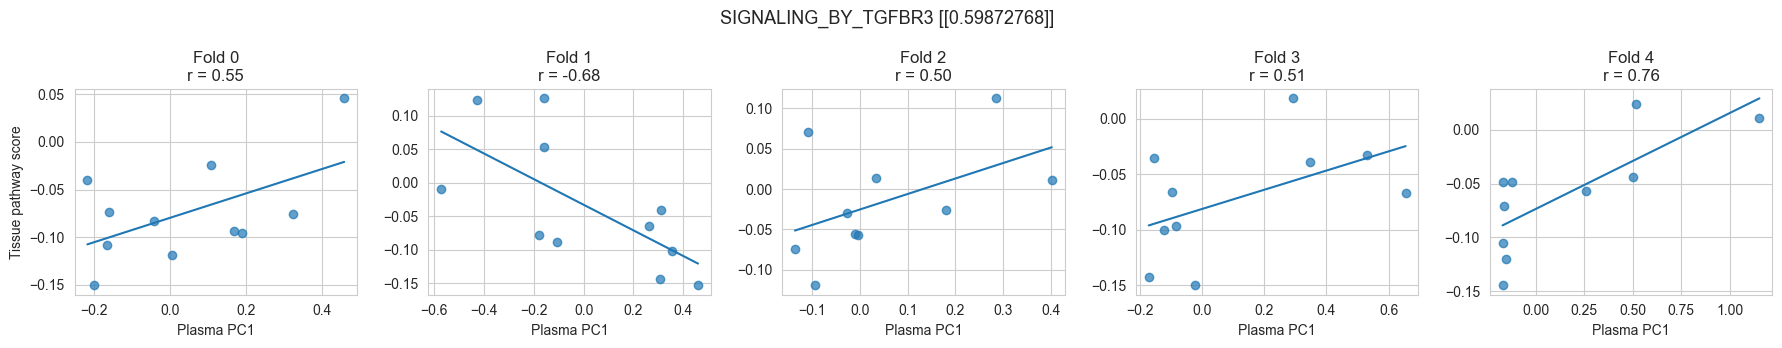

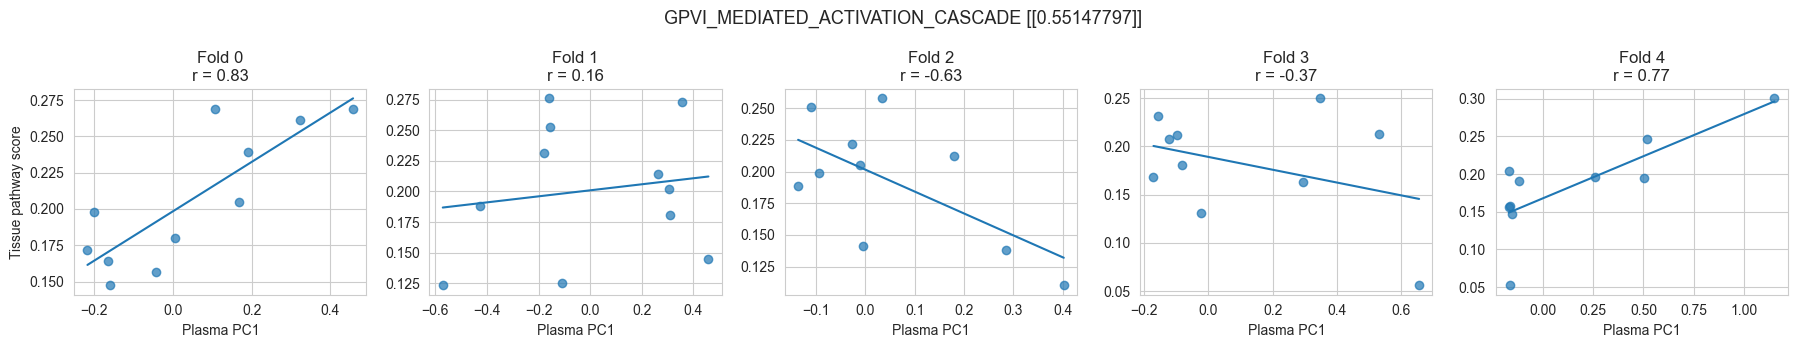

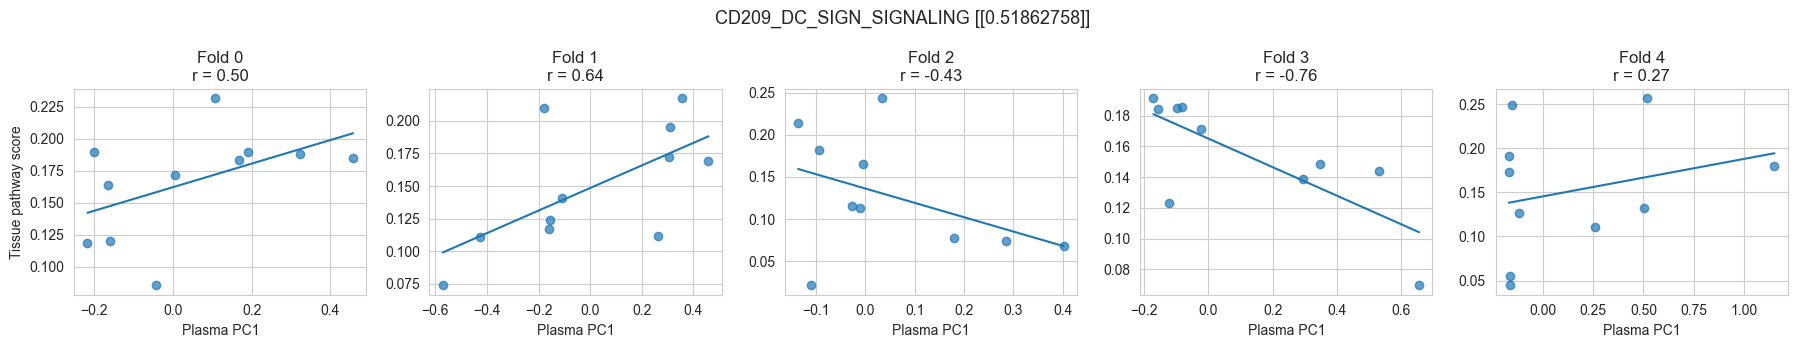

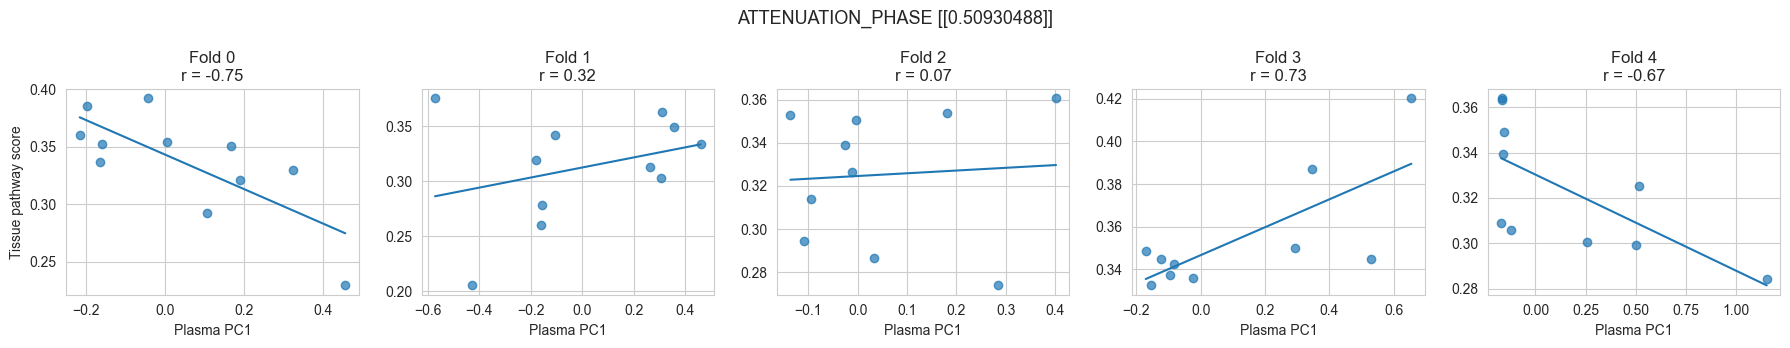

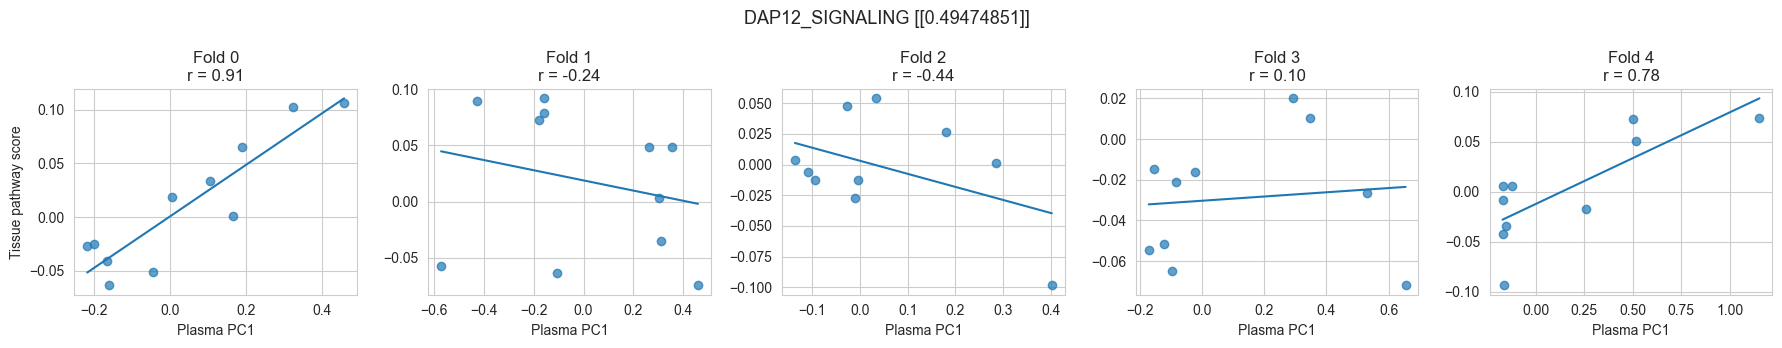

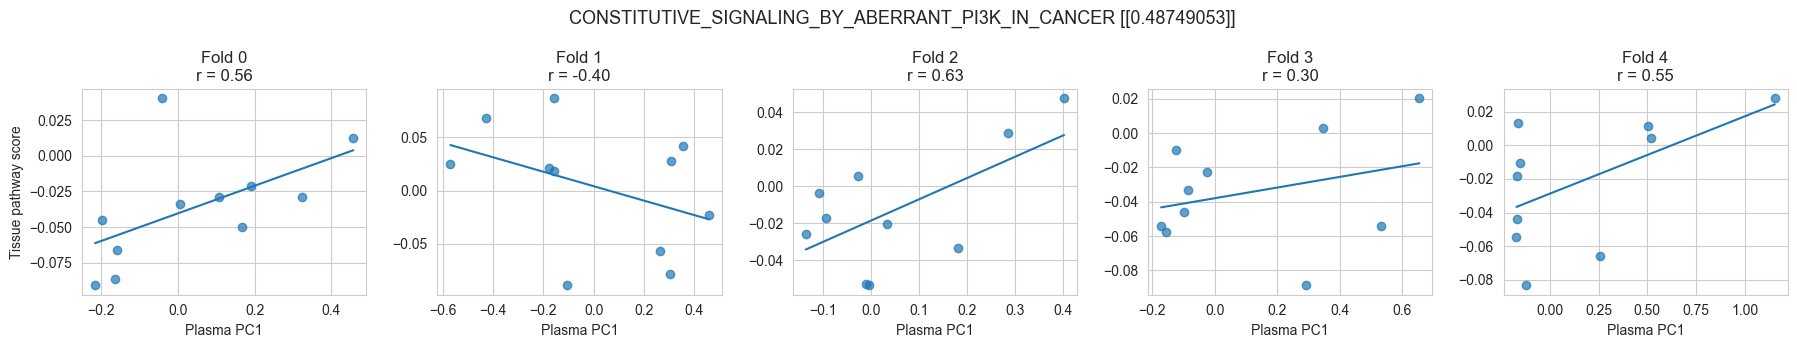

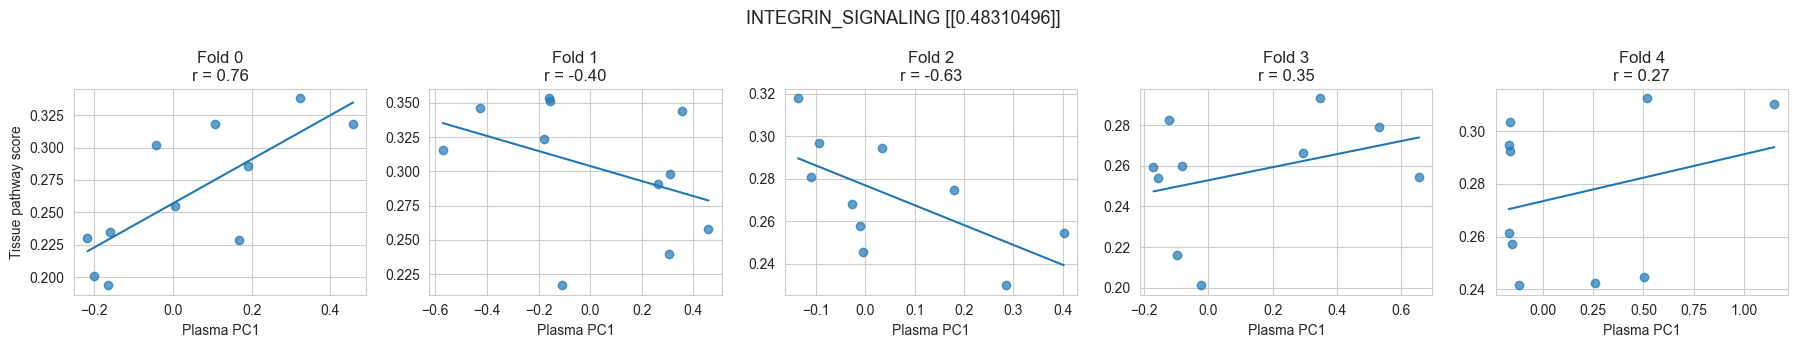

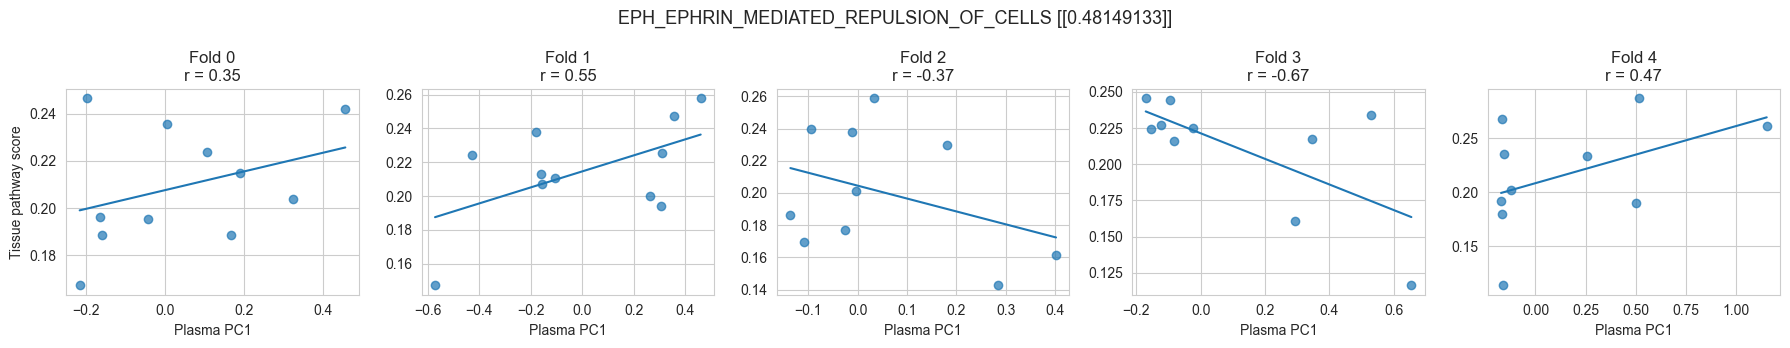

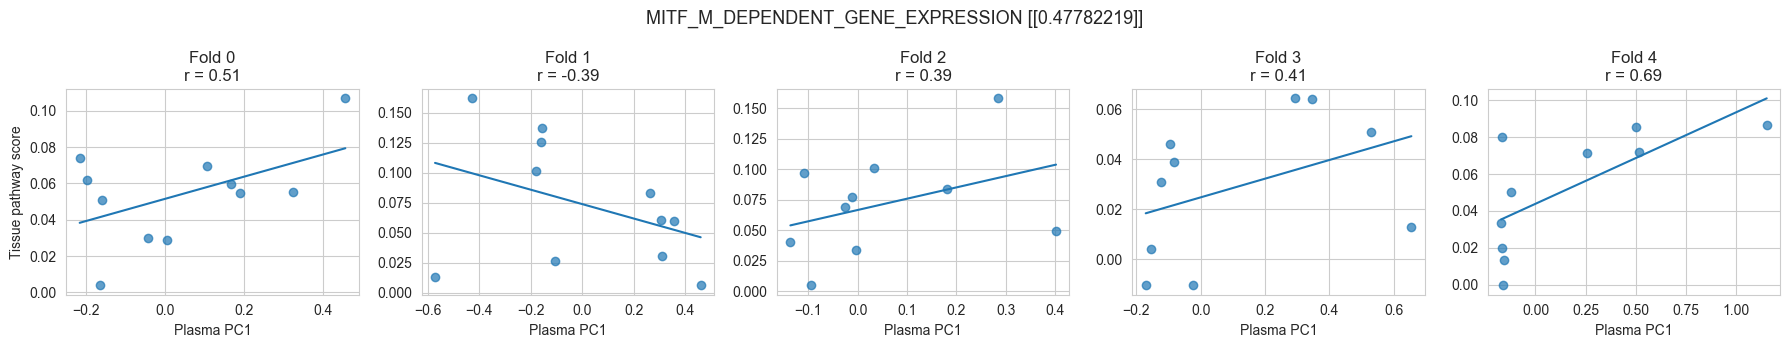

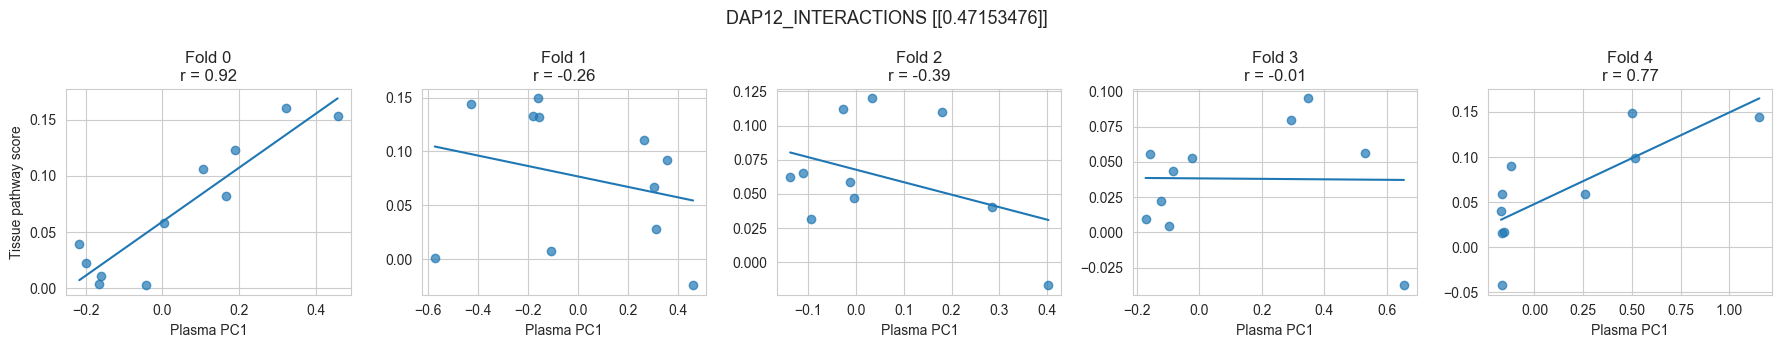

In [128]:
import matplotlib.pyplot as plt
import numpy as np

for pathway in top_pearson_PC1_index:

    pathway_df = cross_plasma_to_tissue[
        (cross_plasma_to_tissue["PC"] == "PC1") &
        (cross_plasma_to_tissue["pathway"] == pathway)
    ]

    fig, axes = plt.subplots(
        1, 5,
        figsize=(18, 3.5),
        sharex=False,
        sharey=False
    )

    for ax, (_, row) in zip(axes, pathway_df.iterrows()):

        fold = row["fold"]

        # Get the actual patient-level data for this fold
        fold_data = plasma_pc_tissue_pathways[
            plasma_pc_tissue_pathways["fold"] == fold
        ]

        x = fold_data["PC1"]
        y = fold_data[pathway]

        ax.scatter(x, y, alpha=0.7)

        # Regression line
        if len(x) >= 3:
            z = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = z[0] * x_line + z[1]
            ax.plot(x_line, y_line)

        ax.set_title(
            f"Fold {int(fold)}\n"
            f"r = {row['pearson_r']:.2f}"
        )

        ax.set_xlabel("Plasma PC1")

    axes[0].set_ylabel("Tissue pathway score")
    abs_r = pathway_df.agg(pearson_mean_abs_r=("pearson_r", lambda x: x.abs().mean()))

    fig.suptitle(
        f'{pathway.replace("REACTOME_", "")} {(abs_r.values)}',
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

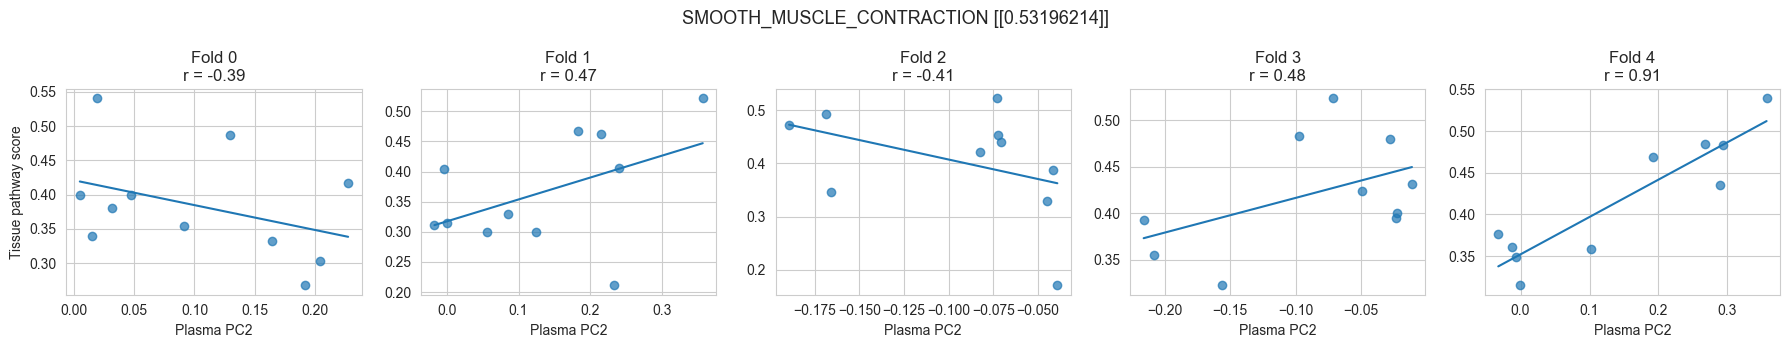

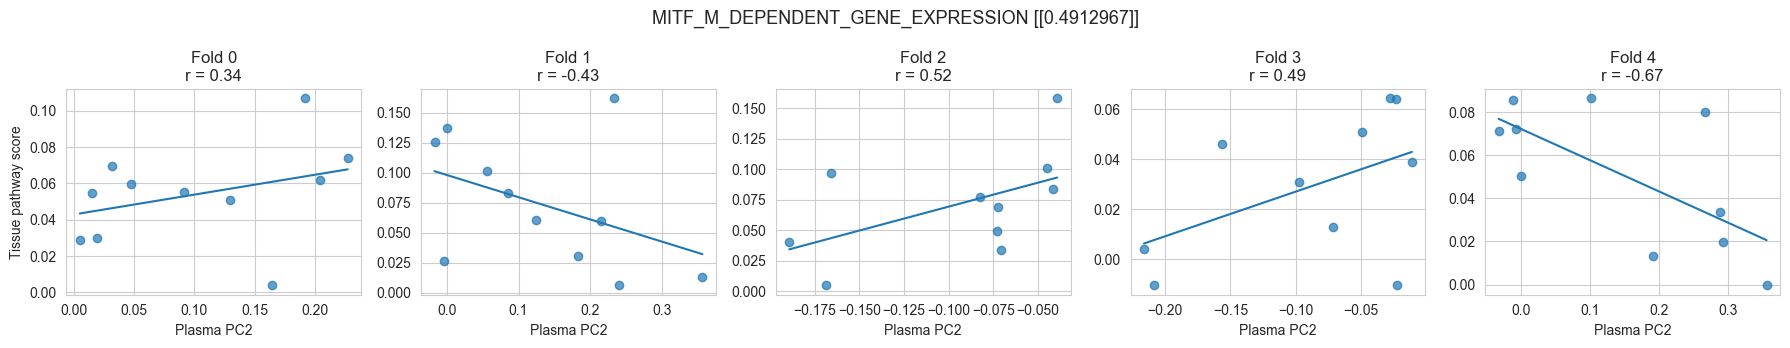

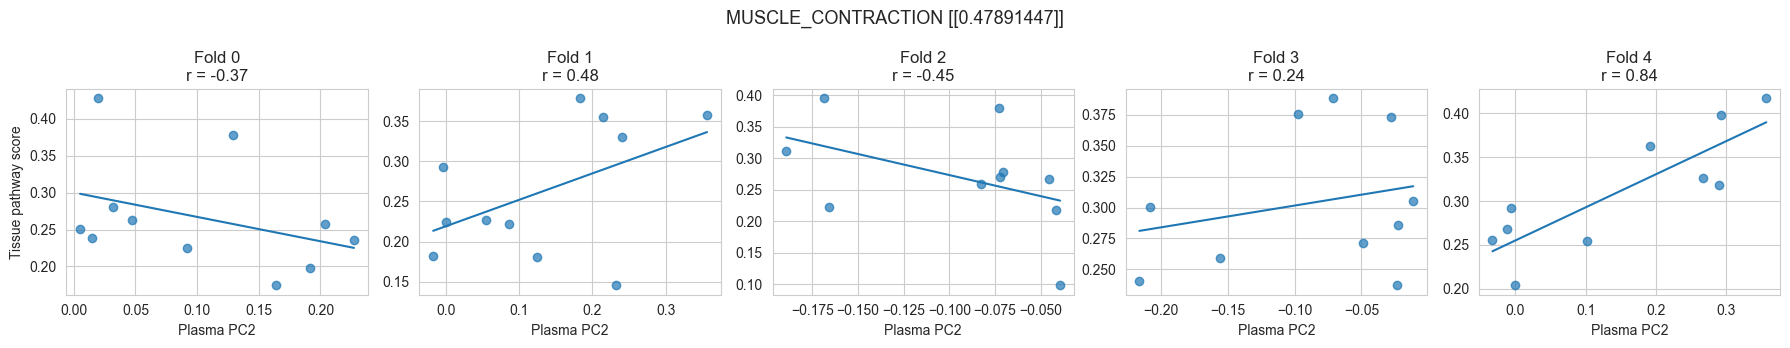

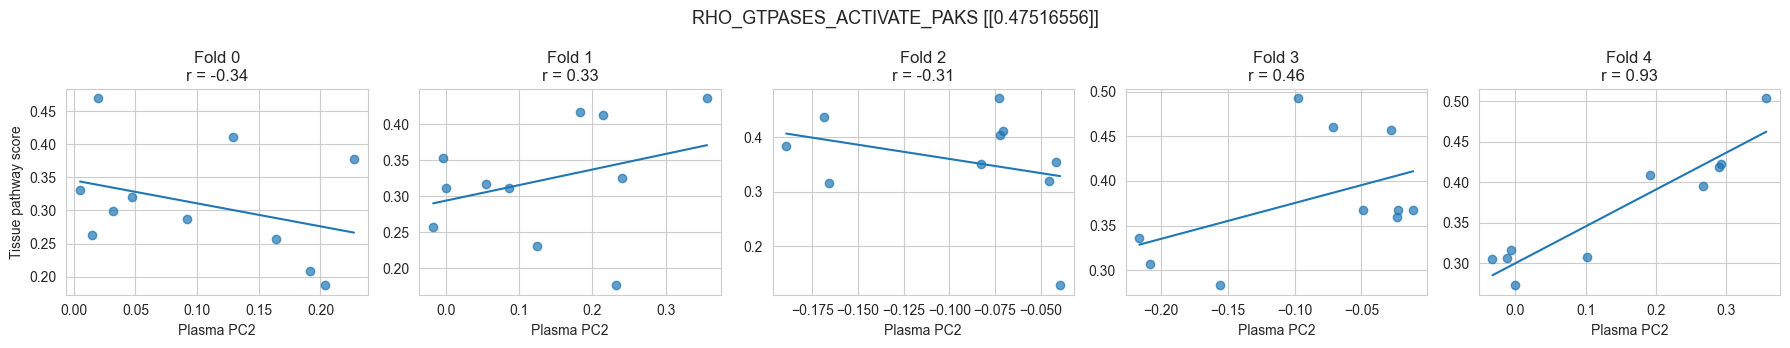

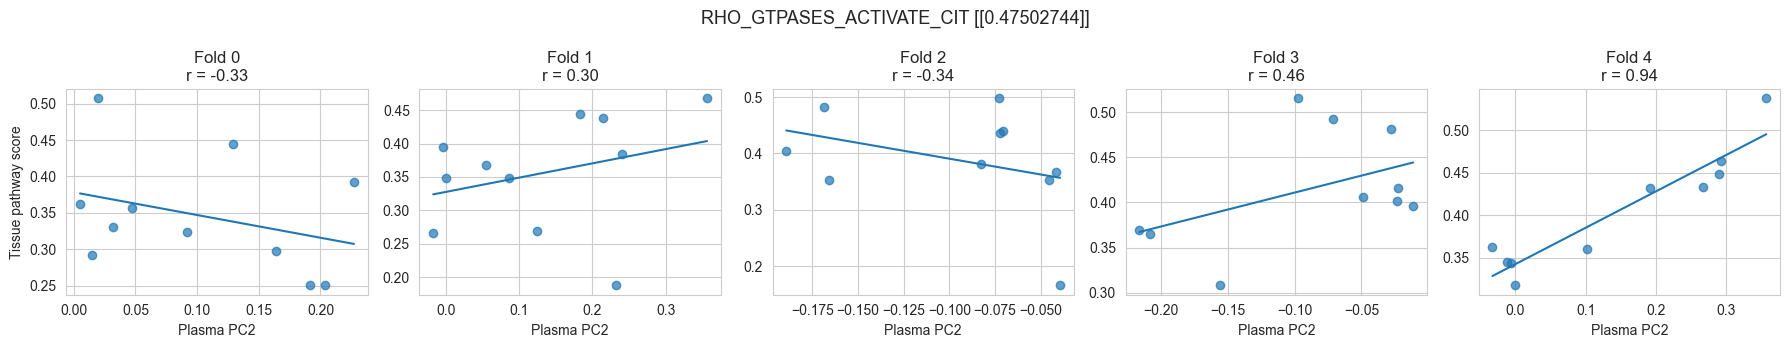

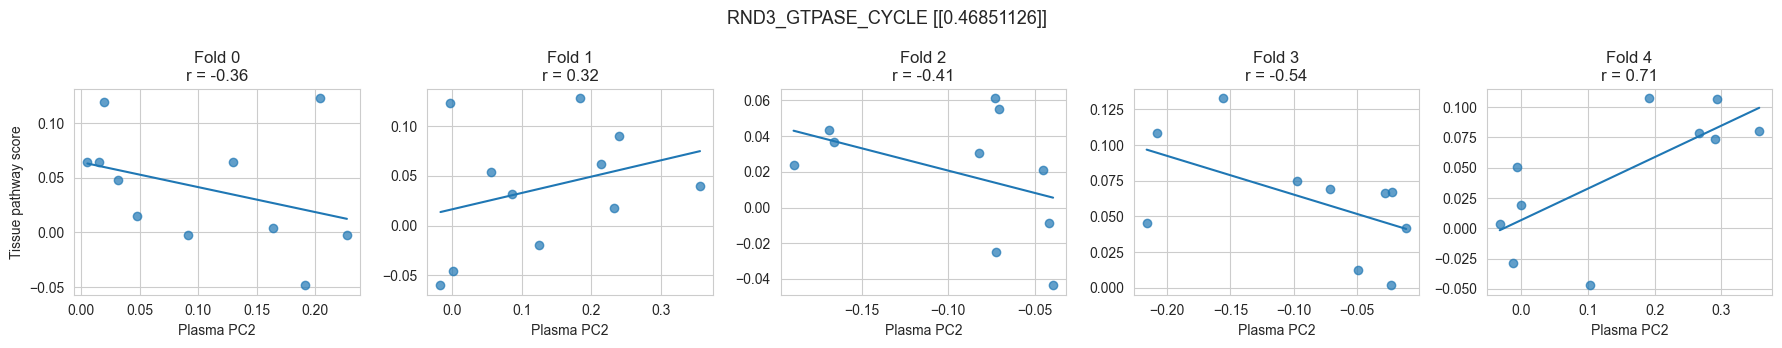

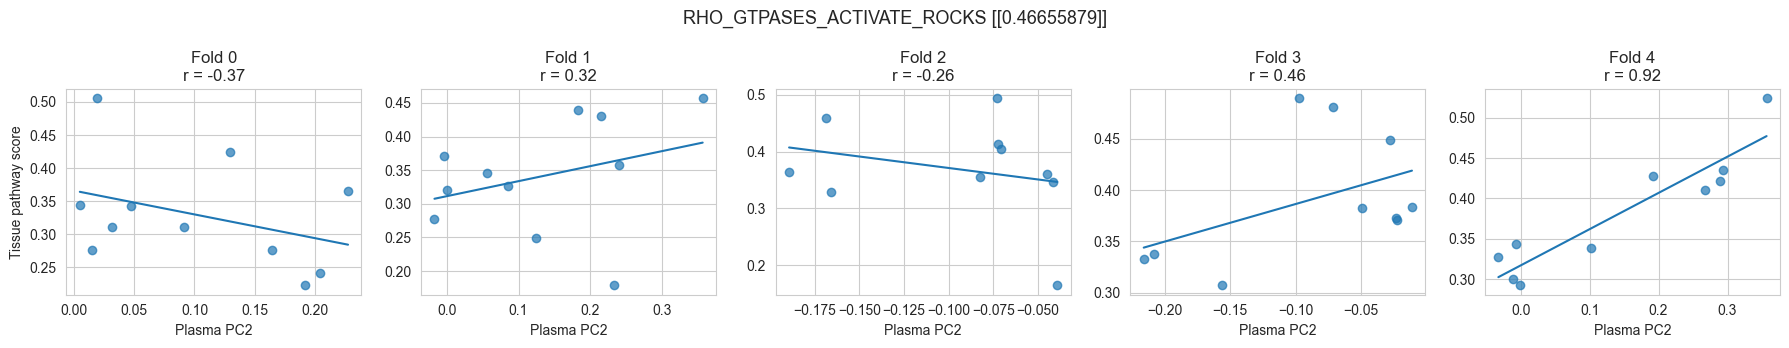

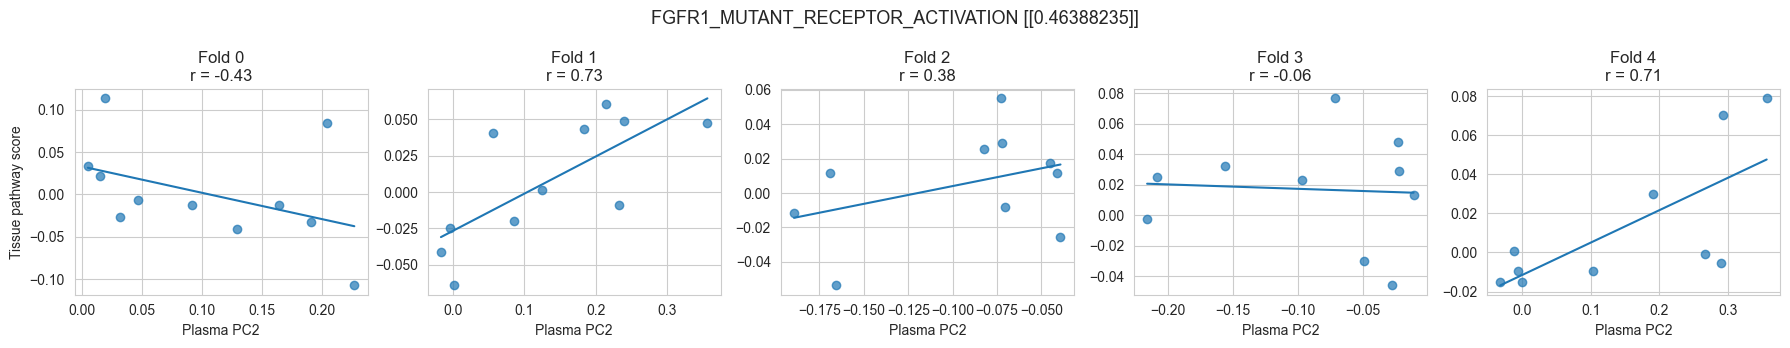

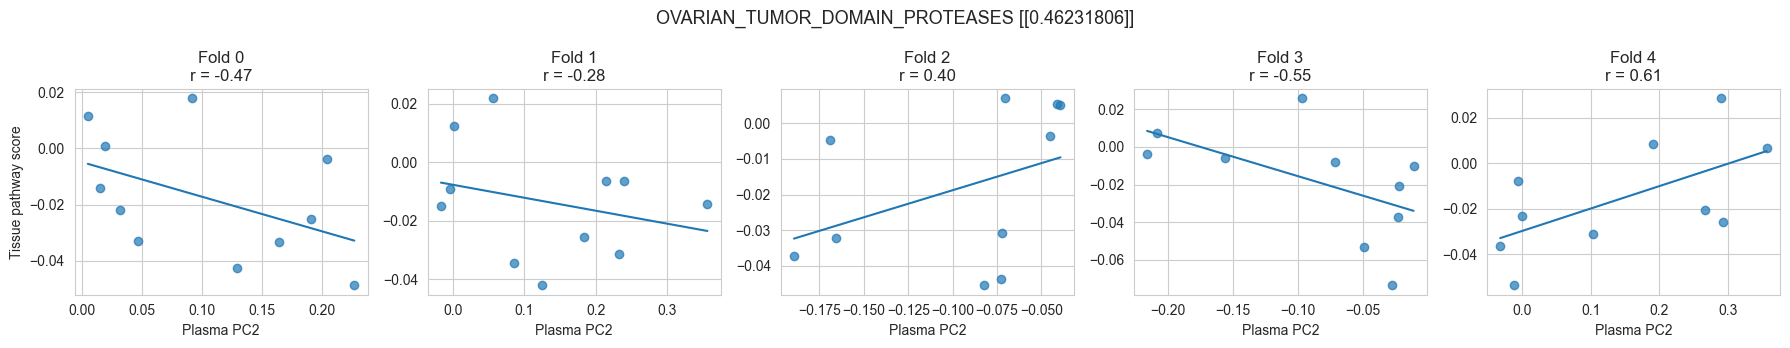

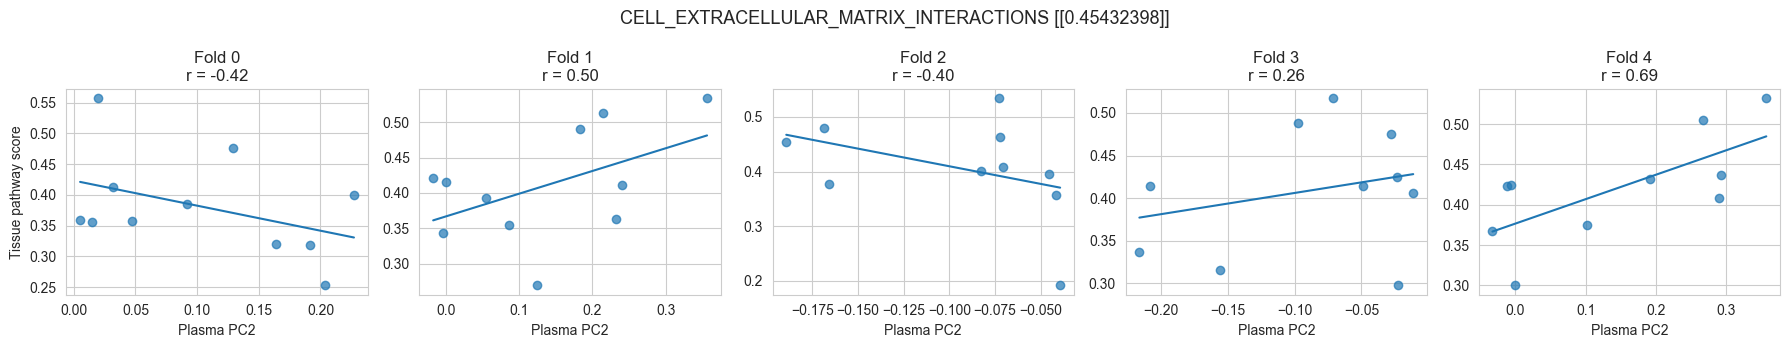

In [130]:
import matplotlib.pyplot as plt
import numpy as np

for pathway in top_pearson_PC2_index:

    pathway_df = cross_plasma_to_tissue[
        (cross_plasma_to_tissue["PC"] == "PC2") &
        (cross_plasma_to_tissue["pathway"] == pathway)
    ]

    fig, axes = plt.subplots(
        1, 5,
        figsize=(18, 3.5),
        sharex=False,
        sharey=False
    )

    for ax, (_, row) in zip(axes, pathway_df.iterrows()):

        fold = row["fold"]

        # Get the actual patient-level data for this fold
        fold_data = plasma_pc_tissue_pathways[
            plasma_pc_tissue_pathways["fold"] == fold
        ]

        x = fold_data["PC2"]
        y = fold_data[pathway]

        ax.scatter(x, y, alpha=0.7)

        # Regression line
        if len(x) >= 3:
            z = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = z[0] * x_line + z[1]
            ax.plot(x_line, y_line)

        ax.set_title(
            f"Fold {int(fold)}\n"
            f"r = {row['pearson_r']:.2f}"
        )

        ax.set_xlabel("Plasma PC2")

    axes[0].set_ylabel("Tissue pathway score")
    abs_r = pathway_df.agg(pearson_mean_abs_r=("pearson_r", lambda x: x.abs().mean()))

    fig.suptitle(
        f'{pathway.replace("REACTOME_", "")} {(abs_r.values)}',
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

In [122]:
print(top_pearson)

Index(['REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION',
       'REACTOME_RND3_GTPASE_CYCLE', 'REACTOME_SMOOTH_MUSCLE_CONTRACTION',
       'REACTOME_SIGNALING_BY_TGFBR3', 'REACTOME_DAP12_INTERACTIONS',
       'REACTOME_SENSORY_PROCESSING_OF_SOUND_BY_OUTER_HAIR_CELLS_OF_THE_COCHLEA',
       'REACTOME_RHO_GTPASES_ACTIVATE_PKNS',
       'REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE', 'REACTOME_DAP12_SIGNALING',
       'REACTOME_HSF1_DEPENDENT_TRANSACTIVATION'],
      dtype='str', name='pathway')


In [209]:
print(type(top_pearson))
print(type(pathway_correlations))
print(pathway_correlations.head())

<class 'pandas.Index'>
<class 'pandas.DataFrame'>
                                             pathway   n  pearson_r  \
0  REACTOME_DEVELOPMENTAL_CELL_LINEAGES_OF_THE_EX...  52  -0.107435   
1            REACTOME_FORMATION_OF_PARAXIAL_MESODERM  52  -0.040573   
2                       REACTOME_SARS_COV_INFECTIONS  52  -0.128560   
3          REACTOME_INITIAL_TRIGGERING_OF_COMPLEMENT  52   0.167309   
4       REACTOME_TRANSCRIPTIONAL_REGULATION_BY_RUNX2  52  -0.008501   

   pearson_p  spearman_r  spearman_p  
0   0.448398   -0.040724    0.774384  
1   0.775198   -0.108683    0.443113  
2   0.363720   -0.172885    0.220335  
3   0.235806    0.201400    0.152221  
4   0.952303   -0.098267    0.488267  


In [202]:
print(len(plot_data['pathway']))

50


In [214]:
pathway_comp = (
    cross_plasma_to_tissue[
        (cross_plasma_to_tissue["PC"] == "PC2") &
        (cross_plasma_to_tissue["pathway"].isin(top_pearson))
    ]
    .groupby("pathway")
    .agg(
        pc_pathway_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .reset_index()
)

pathway_correlations_1 = pathway_correlations[
    pathway_correlations["pathway"].isin(top_pearson)
][["pathway", "pearson_r"]]

pathway_comp = pathway_comp.merge(
    pathway_correlations_1,
    on="pathway",
    how="left"
)

pathway_comp = pathway_comp.rename(columns={
    "pc_pathway_abs_r": "PC2 plasma → tissue pathway |r|",
    "pearson_r": "Plasma pathway ↔ tissue pathway r"
})

print(pathway_comp.head(10))

                                             pathway  \
0                         REACTOME_ATTENUATION_PHASE   
1                   REACTOME_CD209_DC_SIGN_SIGNALING   
2  REACTOME_CONSTITUTIVE_SIGNALING_BY_ABERRANT_PI...   
3    REACTOME_EPH_EPHRIN_MEDIATED_REPULSION_OF_CELLS   
4          REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE   
5                        REACTOME_INTEGRIN_SIGNALING   
6          REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION   
7                         REACTOME_RND3_GTPASE_CYCLE   
8                       REACTOME_SIGNALING_BY_TGFBR3   
9  REACTOME_SYNTHESIS_OF_PIPS_AT_THE_PLASMA_MEMBRANE   

   PC2 plasma → tissue pathway |r|  Plasma pathway ↔ tissue pathway r  
0                         0.464834                                NaN  
1                         0.499300                                NaN  
2                         0.457290                                NaN  
3                         0.460089                                NaN  
4                      

In [215]:
pathway_comp.head(10)

,pathway,PC2 plasma → tissue pathway |r|,Plasma pathway ↔ tissue pathway r
0,REACTOME_ATTENUATION_PHASE,0.464834,NaN
1,REACTOME_CD209_DC_SIGN_SIGNALING,0.499300,NaN
2,REACTOME_CONSTITUTIVE_SIGNALING_BY_ABERRANT_PI...,0.457290,NaN
3,REACTOME_EPH_EPHRIN_MEDIATED_REPULSION_OF_CELLS,0.460089,NaN
4,REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.537829,NaN
5,REACTOME_INTEGRIN_SIGNALING,0.495519,-0.128994
6,REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.472715,-0.228976
7,REACTOME_RND3_GTPASE_CYCLE,0.462946,NaN
8,REACTOME_SIGNALING_BY_TGFBR3,0.574773,NaN
9,REACTOME_SYNTHESIS_OF_PIPS_AT_THE_PLASMA_MEMBRANE,0.457041,NaN


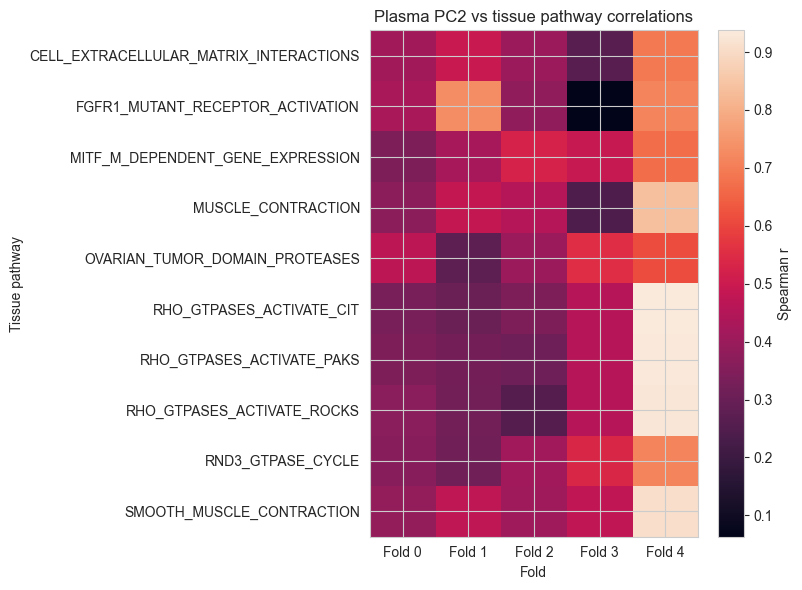

In [134]:
plt.figure(figsize=(8, 6))

plt.imshow(
    plot_df_PC2,
    aspect="auto"
)

plt.xticks(
    range(len(plot_df_PC2.columns)),
    [f"Fold {x}" for x in plot_df_PC2.columns]
)

plt.yticks(
    range(len(plot_df_PC2.index)),
    [
        x.replace("REACTOME_", "")
        for x in plot_df_PC2.index
    ]
)

plt.colorbar(label="Spearman r")

plt.xlabel("Fold")
plt.ylabel("Tissue pathway")
plt.title("Plasma PC2 vs tissue pathway correlations")

plt.tight_layout()
plt.show()

In [140]:
summary_plasma_to_tissue[
    (summary_plasma_to_tissue["PC"] == "PC2") &
    (summary_plasma_to_tissue["n_folds"] == 5)
].sort_values(['spearman_mean_abs_r'],
    ascending=False
).head(30)

,PC,pathway,pearson_mean_abs_r,pearson_median_abs_r,pearson_min_abs_r,pearson_max_abs_r,spearman_mean_abs_r,spearman_median_abs_r,spearman_min_abs_r,spearman_max_abs_r,n_folds
1468,PC2,REACTOME_SIGNALING_BY_TGFBR3,0.574773,0.516309,0.461192,0.774497,0.577576,0.660606,0.318182,0.818182,5
823,PC2,REACTOME_ARACHIDONATE_METABOLISM,0.434634,0.479960,0.153729,0.569800,0.540000,0.545455,0.463636,0.672727,5
855,PC2,REACTOME_CD209_DC_SIGN_SIGNALING,0.499300,0.481970,0.274181,0.753076,0.503030,0.500000,0.357576,0.709091,5
1024,PC2,REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROT...,0.415396,0.253318,0.123416,0.796729,0.500606,0.345455,0.236364,0.866667,5
861,PC2,REACTOME_CELLULAR_RESPONSE_TO_CHEMICAL_STRESS,0.367993,0.401709,0.074735,0.617684,0.496970,0.527273,0.224242,0.727273,5
917,PC2,REACTOME_DAP12_INTERACTIONS,0.400718,0.158422,0.028370,0.884269,0.491515,0.381818,0.115152,0.878788,5
1170,PC2,REACTOME_MITF_M_REGULATED_MELANOCYTE_DEVELOPMENT,0.418732,0.427511,0.127697,0.756171,0.473939,0.466667,0.263636,0.696970,5
1169,PC2,REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.472715,0.440410,0.290073,0.715812,0.472121,0.442424,0.190909,0.793939,5
1104,PC2,REACTOME_INTEGRIN_SIGNALING,0.495519,0.390553,0.224675,0.797647,0.470909,0.472727,0.127273,0.721212,5
1075,PC2,REACTOME_HEPARAN_SULFATE_HEPARIN_HS_GAG_METABO...,0.411043,0.489249,0.063085,0.578344,0.470303,0.481818,0.175758,0.806061,5


In [129]:
cross_tissue_to_plasma[
    cross_tissue_to_plasma["PC"] == "PC2"
].sort_values(
    ["pearson_fdr",'spearman_r'],
    ascending=True
).head(50)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold,pearson_fdr,spearman_fdr
2502,PC2,REACTOME_SIGNALING_BY_VEGF,10,-0.976303,0.000001,-0.842424,0.002220,3,0.000974,0.012567
2902,PC2,REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSI...,10,-0.971598,0.000003,-0.939394,0.000055,4,0.001012,0.003219
3036,PC2,REACTOME_NERVOUS_SYSTEM_DEVELOPMENT,10,-0.967378,0.000005,-0.830303,0.002940,4,0.001052,0.014406
2940,PC2,REACTOME_DISEASES_OF_SIGNAL_TRANSDUCTION_BY_GR...,10,-0.967011,0.000005,-0.818182,0.003815,4,0.001052,0.016254
1095,PC2,REACTOME_INTERFERON_SIGNALING,11,-0.953240,0.000006,-0.881818,0.000330,1,0.001097,0.006260
2864,PC2,REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION,10,-0.964607,0.000007,-0.769697,0.009222,4,0.001097,0.026624
1703,PC2,REACTOME_GLYCOSAMINOGLYCAN_METABOLISM,10,-0.959713,0.000011,-0.963636,0.000007,2,0.001138,0.001289
412,PC2,REACTOME_ELASTIC_FIBRE_FORMATION,11,-0.946442,0.000010,-0.936364,0.000022,0,0.001138,0.001853
965,PC2,REACTOME_ANTIMICROBIAL_MECHANISM_OF_IFN_STIMUL...,11,-0.942812,0.000014,-0.927273,0.000040,1,0.001138,0.002930
1152,PC2,REACTOME_PLATELET_AGGREGATION_PLUG_FORMATION,11,-0.947603,0.000009,-0.881818,0.000330,1,0.001138,0.006260


In [121]:
cross_tissue_to_plasma.columns

Index(['PC', 'pathway', 'n', 'pearson_r', 'pearson_p', 'spearman_r',
       'spearman_p', 'fold', 'pearson_fdr', 'spearman_fdr'],
      dtype='str')

In [116]:
cross_plasma_to_tissue[
    cross_plasma_to_tissue["PC"] == "PC2"
].sort_values(
    "pearson_r",
    ascending=True
).head(20)

,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold,pearson_fdr,spearman_fdr
7687,PC2,REACTOME_RND2_GTPASE_CYCLE,10,-0.908319,0.000276,-0.939394,0.000055,4,0.593317,0.262128
917,PC2,REACTOME_DAP12_INTERACTIONS,11,-0.884269,0.000302,-0.809091,0.002559,0,0.593317,0.510981
918,PC2,REACTOME_DAP12_SIGNALING,11,-0.867467,0.000541,-0.809091,0.002559,0,0.709869,0.510981
7688,PC2,REACTOME_RND3_GTPASE_CYCLE,10,-0.843226,0.002177,-0.781818,0.007547,4,0.777489,0.535090
2617,PC2,REACTOME_GLUCOSE_METABOLISM,11,-0.834927,0.001384,-0.709091,0.014552,1,0.777489,0.612431
1014,PC2,REACTOME_FLT3_SIGNALING,11,-0.824939,0.001775,-0.836364,0.001333,0,0.777489,0.476917
1430,PC2,REACTOME_SIGNALING_BY_CSF1_M_CSF_IN_MYELOID_CELLS,11,-0.823350,0.001844,-0.881818,0.000330,0,0.777489,0.338028
1335,PC2,REACTOME_REGULATION_OF_SIGNALING_BY_CBL,11,-0.797743,0.003260,-0.818182,0.002083,0,0.873036,0.510981
1104,PC2,REACTOME_INTEGRIN_SIGNALING,11,-0.797647,0.003267,-0.700000,0.016471,0,0.873036,0.641716
7320,PC2,REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROT...,10,-0.796729,0.005797,-0.866667,0.001174,4,0.931096,0.461787
